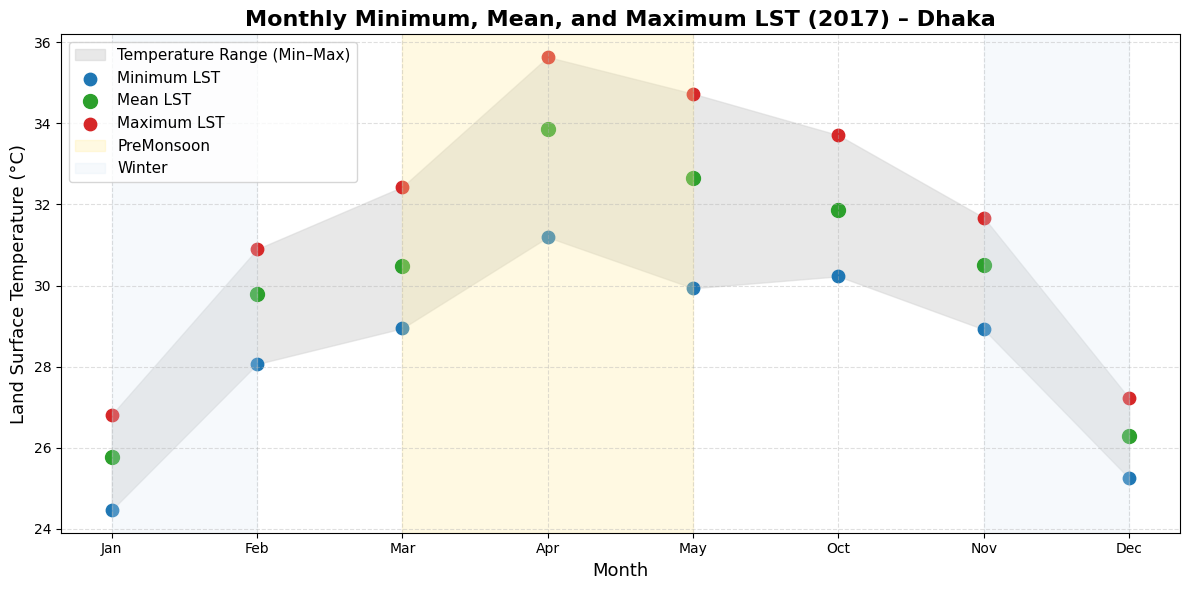

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure correct month order
order = ["Jan", "Feb", "Mar", "Apr", "May", "Oct", "Nov", "Dec"]

# Calculate min, mean, and max from lst_values and create stats_df
data = {
    'Min': [np.nanmin(lst_values[month]) for month in order],
    'Mean': [np.nanmean(lst_values[month]) for month in order],
    'Max': [np.nanmax(lst_values[month]) for month in order]
}
stats_df = pd.DataFrame(data, index=order)

plt.figure(figsize=(12, 6))

# Shaded band between min and max
plt.fill_between(
    stats_df.index,
    stats_df["Min"],
    stats_df["Max"],
    color="lightgray",
    alpha=0.5,
    label="Temperature Range (Min–Max)"
)

# Points only (no lines)
plt.scatter(stats_df.index, stats_df["Min"], color="#1f77b4", s=80, label="Minimum LST")
plt.scatter(stats_df.index, stats_df["Mean"], color="#2ca02c", s=100, label="Mean LST")
plt.scatter(stats_df.index, stats_df["Max"], color="#d62728", s=80, label="Maximum LST")

# Seasonal shading
plt.axvspan("Mar", "May", color="#ffeda0", alpha=0.3, label="PreMonsoon")
plt.axvspan("Jan", "Feb", color="#deebf7", alpha=0.25)
plt.axvspan("Nov", "Dec", color="#deebf7", alpha=0.25, label="Winter")

plt.title("Monthly Minimum, Mean, and Maximum LST (2017) – Dhaka", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=13)
plt.ylabel("Land Surface Temperature (°C)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:

# Assuming lst_values["Apr"] and lst_values["Dec"] exist and are numpy arrays
apr_lst = lst_values["Apr"]
dec_lst = lst_values["Dec"]

delta_lst = apr_lst - dec_lst  # April minus December

zone_table = pd.DataFrame({
    "Zone": zones["NAME_3"],
    "LST_April": apr_lst,
    "LST_December": dec_lst,
    "Delta_LST_Apr_Dec": delta_lst
})

# Sort by largest warming (or cooling)
zone_table_sorted = zone_table.sort_values("Delta_LST_Apr_Dec", ascending=False)

print(zone_table_sorted.head(10))  # top 10 most positive ΔLST

                  Zone  LST_April  LST_December  Delta_LST_Apr_Dec
22              Mirpur  35.254762     26.402143           8.852619
0               Adabor  34.385000     25.848750           8.536250
2             Bangshal  35.250000     26.746667           8.503333
37     TejgaonInd.Area  35.638889     27.221667           8.417222
5            ChakBazar  35.103333     26.700000           8.403333
9            Dhanmondi  34.646667     26.375000           8.271667
28               Ramna  34.883333     26.683333           8.200000
24           Motijheel  34.930000     26.753333           8.176667
36             Tejgaon  34.860000     26.687500           8.172500
33  Sher-e-banglaNagar  34.540000     26.380000           8.160000


In [ ]:

apr = lst_values["Apr"]
dec = lst_values["Dec"]

delta = apr - dec

df = pd.DataFrame({
    "Zone": zones["NAME_3"],
    "April_LST": apr,
    "December_LST": dec,
    "Delta_LST": delta
})

df_filtered = df[df["Delta_LST"] > 5].sort_values("Delta_LST", ascending=False)
df_filtered


In [ ]:
dhaka_zones = gpd.read_file("/content/drive/MyDrive/Coredhaka.shp")
dhaka_zones = dhaka_zones.to_crs("EPSG:4326")  # ensure WGS84
dhaka_zones.head()


,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
0,BGD.3.1.1_1,BGD,Bangladesh,BGD.3_1,Dhaka,NA,BGD.3.1_1,Dhaka,NA,Adabor,NA,NA,Upazilla,Upazilla,302602,NA,"POLYGON ((90.3587 23.7651, 90.3589 23.7624, 90..."
1,BGD.3.1.2_1,BGD,Bangladesh,BGD.3_1,Dhaka,NA,BGD.3.1_1,Dhaka,NA,Badda,NA,NA,Upazilla,Upazilla,302604,NA,"POLYGON ((90.4261 23.7897, 90.4222 23.8067, 90..."
2,BGD.3.1.3_1,BGD,Bangladesh,BGD.3_1,Dhaka,NA,BGD.3.1_1,Dhaka,NA,Bangshal,NA,NA,Upazilla,Upazilla,302605,NA,"POLYGON ((90.403 23.7116, 90.402 23.7097, 90.3..."
3,BGD.3.1.4_1,BGD,Bangladesh,BGD.3_1,Dhaka,NA,BGD.3.1_1,Dhaka,NA,BimanBandar,NA,NA,Upazilla,Upazilla,302606,NA,"POLYGON ((90.4181 23.8379, 90.4129 23.8335, 90..."
4,BGD.3.1.5_1,BGD,Bangladesh,BGD.3_1,Dhaka,NA,BGD.3.1_1,Dhaka,NA,Cantonment,NA,NA,Upazilla,Upazilla,302608,NA,"POLYGON ((90.4169 23.8198, 90.4178 23.8164, 90..."


In [ ]:
def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = row.geometry

        if geom.geom_type == "Polygon":
            ee_geom = ee.Geometry.Polygon(list(geom.exterior.coords))

        elif geom.geom_type == "MultiPolygon":
            polygons = []
            for poly in geom.geoms:
                polygons.append(list(poly.exterior.coords))
            ee_geom = ee.Geometry.MultiPolygon(polygons)

        else:
            raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

        feat = ee.Feature(ee_geom, {"NAME_3": row["NAME_3"]})
        features.append(feat)

    return ee.FeatureCollection(features)

zones = gdf_to_ee(dhaka_zones)
print("Number of zones in EE:", zones.size().getInfo())


Number of zones in EE: 41


In [ ]:
lst_ic = ee.ImageCollection("MODIS/061/MOD11A2").select("LST_Day_1km")

In [ ]:
def compute_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    col = lst_ic.filterDate(start, end)

    # Skip empty collections
    if col.size().getInfo() == 0:
        print(f"WARNING: No MODIS data for {year}")
        return ee.FeatureCollection([])

    img = (
        col.mean()
           .multiply(0.02)      # scale factor
           .subtract(273.15)    # Kelvin → Celsius
           .rename("LST")
    )

    stats = img.reduceRegions(
        collection=zones,
        reducer=ee.Reducer.mean(),
        scale=1000
    ).map(lambda f: f.set("year", year))

    return stats


In [ ]:
years = list(range(2014, 2025))  # 2014–2024 inclusive

all_fc = ee.FeatureCollection([])
for y in years:
    print("Processing year:", y)
    yearly_fc = compute_year(y)
    all_fc = all_fc.merge(yearly_fc)

Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023
Processing year: 2024


In [ ]:
import geopandas as gpd

zones = gpd.read_file("/content/drive/MyDrive/Coredhaka.shp")

In [ ]:
df_year.to_csv("dhaka_LST_2014_2024.csv", index=False)

In [ ]:
print(dhaka_zones.columns)
print(df_year.columns)


Index(['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2',
       'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3',
       'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry'],
      dtype='object')
Index(['NAME_3', 'mean', 'year'], dtype='object')


In [ ]:
# Function to extract pixel time series for Mann-Kendall
def extract_pixel_timeseries(img_col, geometry, scale=100):
    """
    Extract pixel values over time for spatial trend analysis.
    Note: This requires sampling points or converting to feature collection.
    """
    # Create sample points (grid over ROI)
    grid = ee.FeatureCollection.randomPoints(region=geometry, points=100)

    # Extract values at each point for all images
    def extract_values(img):
        date = img.date().format('YYYY-MM-dd')
        values = img.reduceRegions(
            collection=grid,
            reducer=ee.Reducer.mean(),
            scale=scale
        ).map(lambda f: f.set('date', date).set('LST', f.get('mean')))
        return values

    # Apply to all images (this is computationally intensive)
    all_values = imgCol_merge.map(extract_values).flatten()

    return all_values

# Note: For full spatial analysis, consider using Google Earth Engine's
# built-in Mann-Kendall or exporting pixel time series for external analysis

In [ ]:
import geopandas as gpd
import pandas as pd

# --- Load shapefile ---
shapefile_path = "/content/drive/MyDrive/Coredhaka.shp"
zones_gdf = gpd.read_file(shapefile_path)

# --- Inspect available columns ---
print("Columns in shapefile:", zones_gdf.columns.tolist())
print(zones_gdf.head())

# --- Choose identifier columns dynamically ---
# Adjust based on what you see printed above
# For example, if you see 'ID' or 'ZONE' instead of 'zone_id', use that
possible_cols = ['ID', 'ZONE', 'FID', 'Name', 'poverty', 'population']
selected_cols = [col for col in possible_cols if col in zones_gdf.columns]

# If nothing matches, just take the first few non-geometry columns
if not selected_cols:
    selected_cols = [c for c in zones_gdf.columns if c != 'geometry'][:3]

zone_data = zones_gdf[selected_cols]

# --- Optional: compute population density if population + geometry available ---
if 'population' in zones_gdf.columns:
    zones_gdf['area_km2'] = zones_gdf.geometry.area / 1e6  # assuming CRS in meters
    zones_gdf['population_density'] = zones_gdf['population'] / zones_gdf['area_km2']
    zone_data = zones_gdf[selected_cols + ['population_density']]

# --- Export to CSV ---
csv_path = "/content/zone_data.csv"
zone_data.to_csv(csv_path, index=False)

print(f"Zone data CSV saved to: {csv_path}")
print(zone_data.head())


In [ ]:
# Export ALL non-geometry attributes to CSV
non_geom_cols = [c for c in zones_gdf.columns if c != 'geometry']
zone_data = zones_gdf[non_geom_cols].copy()

zone_csv_path = "/content/zone_data.csv"
zone_data.to_csv(zone_csv_path, index=False)
print("Zone data CSV saved:", zone_csv_path)
print(zone_data.columns.tolist()[:10])
print(zone_data.head())

In [ ]:
# Choose the merge key and zone_id based on actual columns
merge_key = 'SystemIndex'  # present in LST CSV
# Pick your real zone identifier from zone_data columns:
zone_id = 'ID'  # change to 'ZONE' or the correct field that identifies zones


In [ ]:
# Reload zone_data CSV
zone_data = pd.read_csv("/content/zone_data.csv")
print("Zone data columns:", zone_data.columns.tolist())

if merge_key in zone_data.columns:
    merged = pd.merge(lst_df, zone_data, on=merge_key, how='inner')
    print("Merged shape:", merged.shape)
else:
    print(f"'{merge_key}' not in zone_data. Use spatial join (Step 4B).")

Zone data columns: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3']
'SystemIndex' not in zone_data. Use spatial join (Step 4B).


In [ ]:
def analyze_by_zones(lst_df, zone_data, zone_id_col):
    # Merge on the correct key
    if "ID" in lst_df.columns and "zone_id" in zone_data.columns:
        merged = pd.merge(lst_df, zone_data, left_on="ID", right_on="zone_id", how="inner")
        zone_id = "zone_id"
    elif "ID" in lst_df.columns and "ID" in zone_data.columns:
        merged = pd.merge(lst_df, zone_data, on="ID", how="inner")
        zone_id = "ID"
    else:
        raise KeyError("No common zone identifier found between LST and zone_data")

    # Compute stats
    zone_stats = merged.groupby(zone_id).agg({
        'MeanLST': ['mean','std','max','min'],
        'poverty_rate': 'first',
        'population_density': 'first'
    }).round(2)

    return zone_stats


In [ ]:
def analyze_by_zones(lst_df, zone_data, zone_id_col):
    # Merge on the correct key
    if "ID" in lst_df.columns and "zone_id" in zone_data.columns:
        merged = pd.merge(lst_df, zone_data, left_on="ID", right_on="zone_id", how="inner")
        zone_id = "zone_id"
    elif "ID" in lst_df.columns and "ID" in zone_data.columns:
        merged = pd.merge(lst_df, zone_data, on="ID", how="inner")
        zone_id = "ID"
    else:
        raise KeyError("No common zone identifier found between LST and zone_data")

    # Compute stats
    zone_stats = merged.groupby(zone_id).agg({
        'MeanLST': ['mean','std','max','min'],
        'poverty_rate': 'first',
        'population_density': 'first'
    }).round(2)

    return zone_stats


In [ ]:
print(zones_gdf.columns.tolist())

['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']


In [ ]:
print(zones_gdf.shape)
print(zones_gdf.crs)
print(zones_gdf.geometry.geom_type.unique())


(41, 17)
EPSG:4326
['Polygon']


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load shapefile
zones_gdf = gpd.read_file("/content/drive/MyDrive/Coredhaka.shp")

# Load CSV exported from Earth Engine
df = pd.read_csv("/content/drive/MyDrive/Dhaka_LST_Landsat8_9_2014_2024_stats.csv")

print(df.head())
print(df.columns)

In [ ]:
# Load the MODIS LST data that has 'NAME_3' and 'mean' columns
df_modis_yearly = pd.read_csv('/content/drive/MyDrive/ARS/Scientific_Project/dhaka_LST_2014_2024.csv')
df_modis_yearly['mean'] = pd.to_numeric(df_modis_yearly['mean'], errors='coerce')
# Ensure 'year' is also correctly parsed as it's needed for sorting
df_modis_yearly['year'] = pd.to_numeric(df_modis_yearly['year'], errors='coerce')
df_modis_yearly = df_modis_yearly.dropna(subset=['NAME_3', 'mean', 'year'])

print('df_modis_yearly loaded successfully. Head and columns:')
print(df_modis_yearly.head())
print(df_modis_yearly.columns)

In [ ]:
import pandas as pd
import pymannkendall as mk

# Ensure df_modis_yearly has columns: NAME_3, Year, mean
# (This DataFrame should be loaded from dhaka_LST_2014_2024.csv)

# Get unique zone names from the 'NAME_3' column
zones = df_modis_yearly['NAME_3'].unique()

results = []

for z in zones:
    # Filter data for the current zone and sort by year, then extract 'mean' LST values
    ts = df_modis_yearly[df_modis_yearly['NAME_3'] == z].sort_values('year')['mean'].values

    # Only perform Mann-Kendall test if there's enough data (at least 2 points)
    if len(ts) >= 2:
        test = mk.original_test(ts)

        results.append({
            'NAME_3': z, # Use NAME_3 as the zone identifier
            'MK_Z': test.z,
            'MK_p': test.p,
            'Trend': test.trend,
            'slope': test.slope # Add Theil-Sen slope
        })
    else:
        results.append({
            'NAME_3': z,
            'MK_Z': None,
            'MK_p': None,
            'Trend': 'insufficient data',
            'slope': None
        })

mk_df = pd.DataFrame(results)

print(mk_df.head())

In [ ]:
df_year.columns
df_year.head()

In [ ]:
zones_gdf.columns.tolist()


In [ ]:
import pandas as pd
df_year = pd.read_csv("/content/drive/MyDrive/ARS/Scientific_Project/dhaka_LST_2014_2024.csv")
df_year.columns.tolist()

['NAME_3', 'mean', 'year']

In [ ]:
df_year.columns


In [ ]:
df_year["year"].value_counts()

In [ ]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from scipy.stats import theilslopes

# ---------------------------------------------------------
# INPUT REQUIREMENT:
# Using df_modis_yearly (from previous steps) with columns:
#   NAME_3 | year | mean
# ---------------------------------------------------------

df_to_analyze = df_modis_yearly.copy() # Use the correct DataFrame

zones = df_to_analyze['NAME_3'].unique()
results = []

for z in zones:
    subset = df_to_analyze[df_to_analyze['NAME_3'] == z].sort_values('year')
    years = subset['year'].values
    lst_values = subset['mean'].values.astype(float) # Ensure LST values are float

    # Skip zones with insufficient data (e.g., less than 5 years for robust trend)
    if len(lst_values) < 5:
        results.append({
            'Zone': z,
            'MK_Z': np.nan,
            'MK_p': np.nan,
            'MK_Trend': 'Insufficient data',
            'TS_Slope_per_year': np.nan,
            'TS_Lower_CI': np.nan,
            'TS_Upper_CI': np.nan
        })
        continue

    # Mann–Kendall Test
    mk_test = mk.original_test(lst_values)

    # Theil–Sen Slope
    # theilslopes expects x, y, not y, x. Years are x, LST values are y.
    slope, intercept, lo_slope, hi_slope = theilslopes(lst_values, years)

    results.append({
        'Zone': z,
        'MK_Z': mk_test.z,
        'MK_p': mk_test.p,
        'MK_Trend': mk_test.trend,
        'TS_Slope_per_year': slope,
        'TS_Lower_CI': lo_slope,
        'TS_Upper_CI': hi_slope
    })

# Convert to DataFrame
trend_df = pd.DataFrame(results)

# Sort by slope (optional)
trend_df = trend_df.sort_values('TS_Slope_per_year', ascending=False)

# Print full table
pd.set_option('display.max_rows', None)
print(trend_df)


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

# Ensure dhaka_zones (which conceptually is zones_gdf here) is loaded
dhaka_zones = gpd.read_file("/content/drive/MyDrive/ARS/Coredhaka.shp")
zones_gdf = dhaka_zones.copy()

# Rename 'Zone' column in trend_df to 'NAME_3' for merging
trend_df = trend_df.rename(columns={'Zone': 'NAME_3'})

# Merge stats into zones using the common 'NAME_3' column
gdf = zones_gdf.merge(trend_df, on='NAME_3', how='left')

In [ ]:
def mk_category(row):
    if pd.isna(row['MK_p']):
        return 'No data'
    if row['MK_p'] < 0.05 and row['MK_Z'] > 0:
        return 'Significant increasing'
    if row['MK_p'] < 0.05 and row['MK_Z'] < 0:
        return 'Significant decreasing'
    return 'No significant trend'

gdf['MK_Class'] = gdf.apply(mk_category, axis=1)

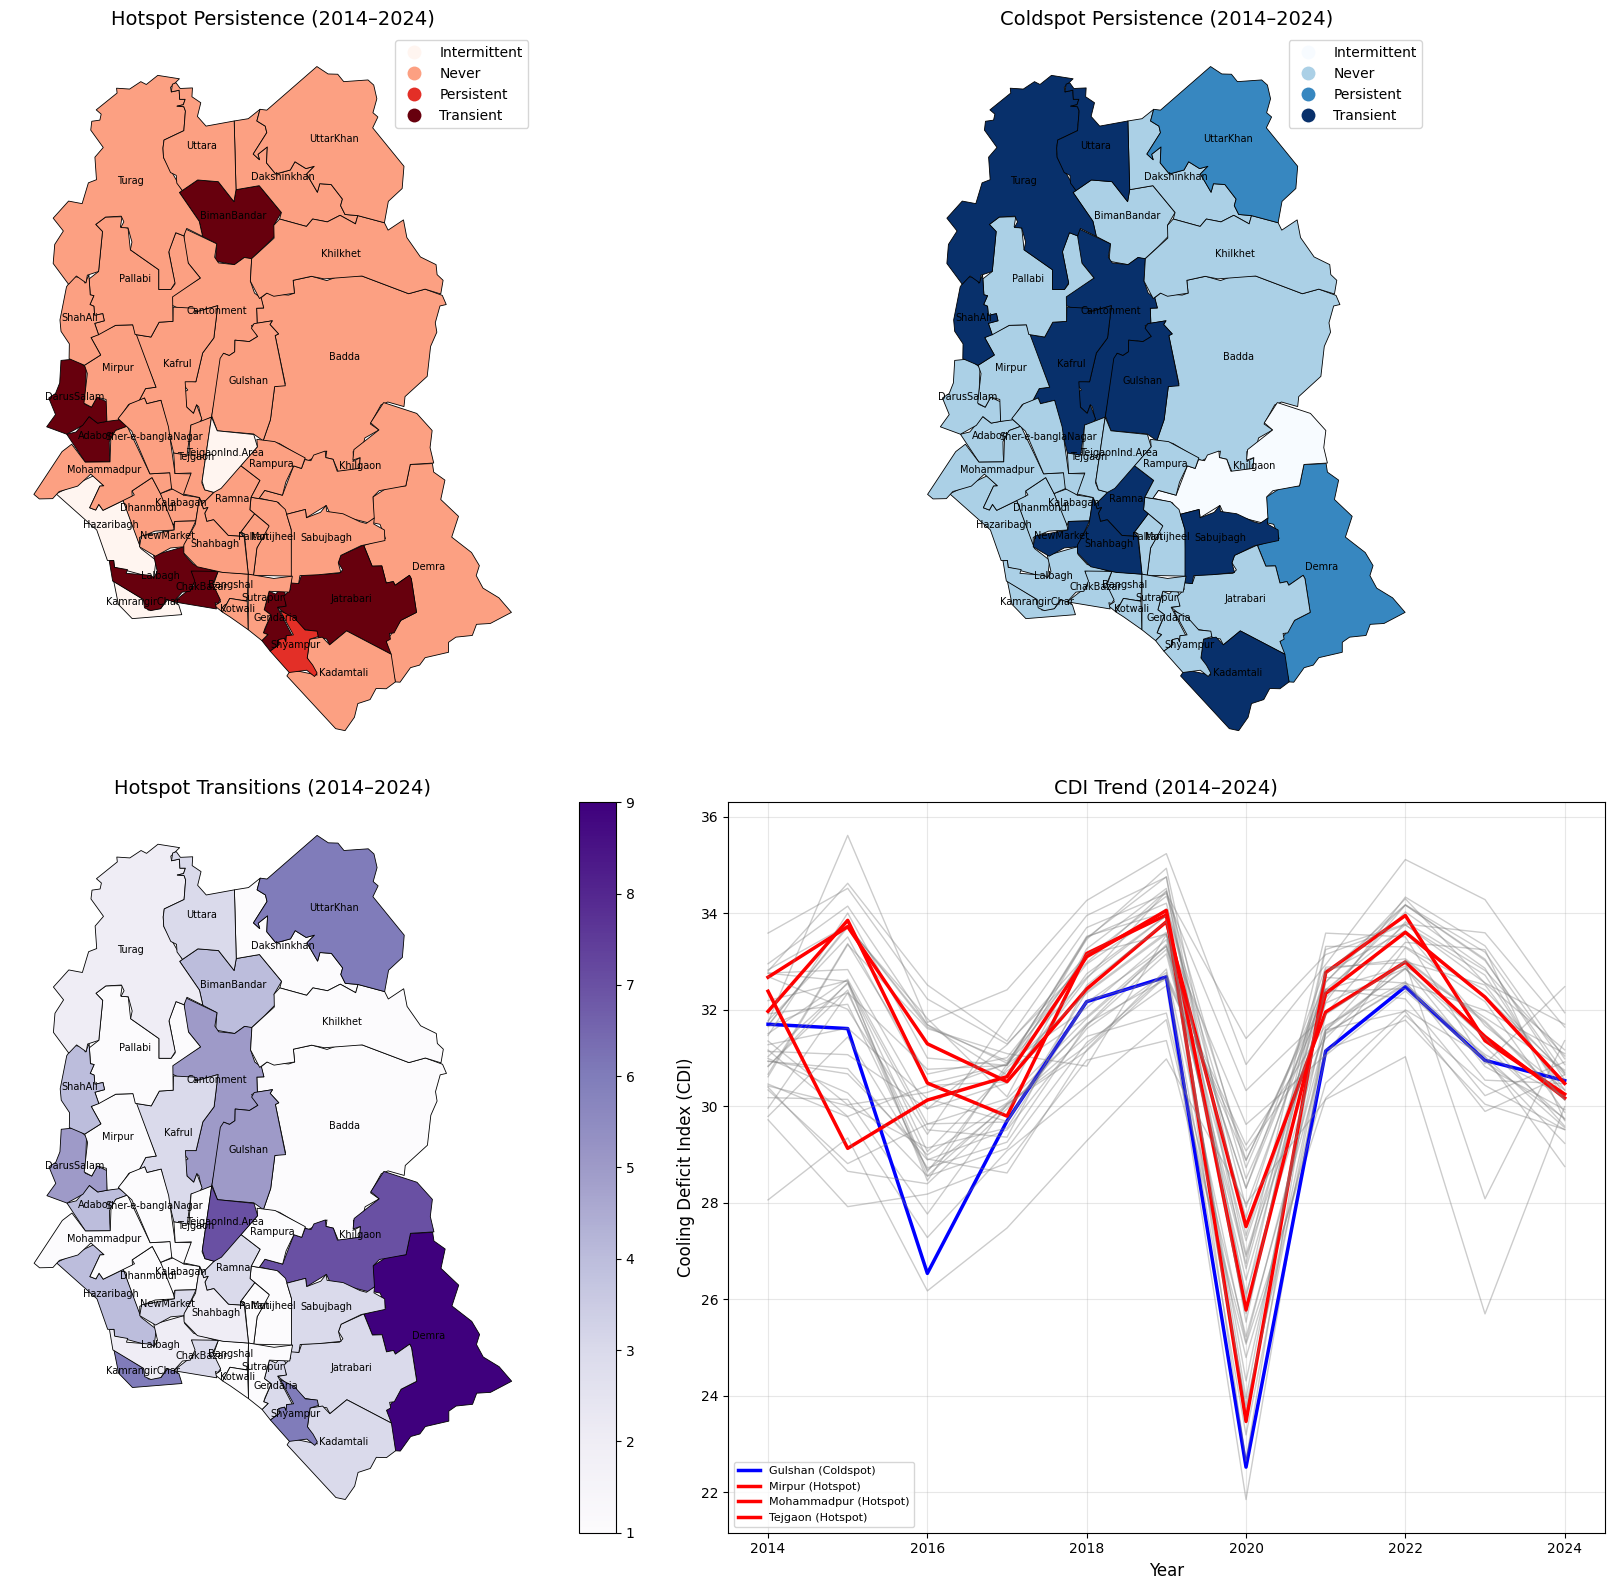

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Highlighted zones
highlight_hot = ["Tejgaon", "Mirpur", "Mohammadpur"]
highlight_cold = ["Hatirjheel", "Gulshan", "Ramna Park"]

# Compute centroids for labeling
gdf["centroid"] = gdf.geometry.centroid
gdf_cold["centroid"] = gdf_cold.geometry.centroid

# Set the correct zone name column, which is 'Zone_Name' after processing in uwIEuP0Snv8J
zone_name_col = 'Zone_Name'

# Add a check to ensure the column exists in gdf (for robustness, though it should be there)
if zone_name_col not in gdf.columns:
    raise ValueError(f"Required column '{zone_name_col}' not found in gdf for labels. Available columns: {gdf.columns.tolist()}")

# Also check for gdf_cold
if zone_name_col not in gdf_cold.columns:
    raise ValueError(f"Required column '{zone_name_col}' not found in gdf_cold for labels. Available columns: {gdf_cold.columns.tolist()}")

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# -------------------------------------------------------
# 1. Hotspot Persistence Map
# -------------------------------------------------------
ax1 = axes[0, 0]
gdf.plot(
    column="Persistence_Class",
    ax=ax1,
    legend=True,
    cmap="Reds",
    edgecolor="black",
    linewidth=0.6
)
for idx, row in gdf.iterrows():
    ax1.text(
        row["centroid"].x,
        row["centroid"].y,
        row[zone_name_col], # Use 'Zone_Name' for map labels
        fontsize=7,
        ha="center"
    )
ax1.set_title("Hotspot Persistence (2014–2024)", fontsize=14)
ax1.axis("off")

# -------------------------------------------------------
# 2. Coldspot Persistence Map
# -------------------------------------------------------
ax2 = axes[0, 1]
gdf_cold.plot(
    column="Coldspot_Class",
    ax=ax2,
    legend=True,
    cmap="Blues",
    edgecolor="black",
    linewidth=0.6
)
for idx, row in gdf_cold.iterrows():
    ax2.text(
        row["centroid"].x,
        row["centroid"].y,
        row[zone_name_col], # Use 'Zone_Name' for map labels
        fontsize=7,
        ha="center"
    )
ax2.set_title("Coldspot Persistence (2014–2024)", fontsize=14)
ax2.axis("off")

# -------------------------------------------------------
# 3. Hotspot Transition Map
# -------------------------------------------------------
ax3 = axes[1, 0]
gdf.plot(
    column="Transitions",
    ax=ax3,
    legend=True,
    cmap="Purples",
    edgecolor="black",
    linewidth=0.6
)
for idx, row in gdf.iterrows():
    ax3.text(
        row["centroid"].x,
        row["centroid"].y,
        row[zone_name_col], # Use 'Zone_Name' for map labels
        fontsize=7,
        ha="center"
    )
ax3.set_title("Hotspot Transitions (2014–2024)", fontsize=14)
ax3.axis("off")

# -------------------------------------------------------
# 4. CDI Trend Plot
# -------------------------------------------------------
ax4 = axes[1, 1]

for zone in df_cdi["Zone_Name"].unique():
    df_zone = df_cdi[df_cdi["Zone_Name"] == zone]

    if zone in highlight_hot:
        ax4.plot(df_zone["Year"], df_zone["CDI"], linewidth=2.5, label=f"{zone} (Hotspot)", color="red")
    elif zone in highlight_cold:
        ax4.plot(df_zone["Year"], df_zone["CDI"], linewidth=2.5, label=f"{zone} (Coldspot)", color="blue")
    else:
        ax4.plot(df_zone["Year"], df_zone["CDI"], linewidth=1, color="gray", alpha=0.4)

ax4.set_title("CDI Trend (2014–2024)", fontsize=14)
ax4.set_xlabel("Year", fontsize=12)
ax4.set_ylabel("Cooling Deficit Index (CDI)", fontsize=12)
ax4.grid(alpha=0.3)
ax4.legend(fontsize=8)

# -------------------------------------------------------
# Final layout
# -------------------------------------------------------
plt.tight_layout()
plt.show()

Processing poverty proxy: LIV_12
Processing poverty proxy: SEC_12
Processing poverty proxy: DW_ROOF
Processing poverty proxy: NB_BUDENS

HPVI comparison across poverty proxies:


,Zone_Name,HPVI_class_LIV_12,HPVI_class_SEC_12,HPVI_class_DW_ROOF,HPVI_class_NB_BUDENS
0,Adabor,6,7,7,8
1,Badda,4,4,5,3
2,Bangshal,4,4,3,5
3,BimanBandar,3,4,4,3
4,Cantonment,0,0,0,0
5,ChakBazar,7,8,8,8
6,Dakshinkhan,0,2,0,0
7,DarusSalam,6,8,7,8
8,Demra,0,2,0,0
9,Dhanmondi,4,3,5,4


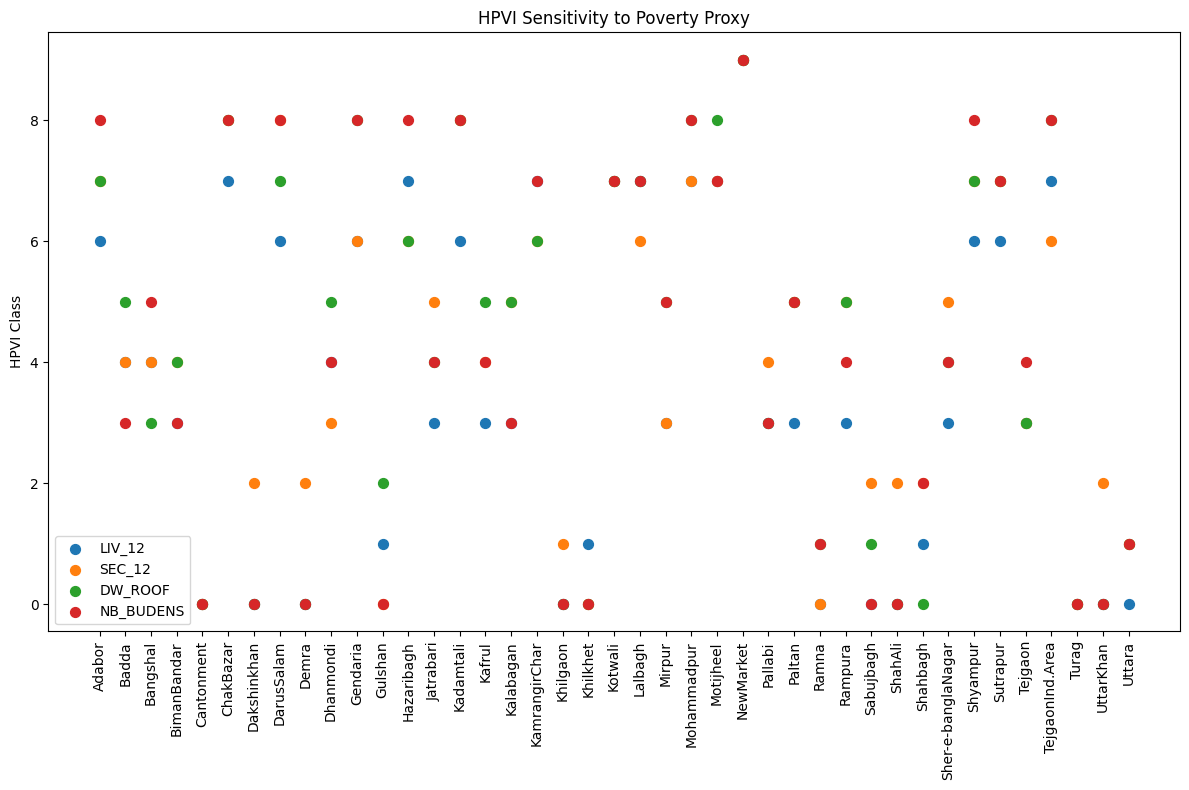

In [ ]:
# =====================================================
# 0. List of poverty proxies for sensitivity check
# =====================================================
poverty_proxies = ["LIV_12", "SEC_12", "DW_ROOF", "NB_BUDENS"]

# Store results for comparison
hpvi_results = {}

# =====================================================
# 1. Loop over poverty proxies
# =====================================================
for proxy in poverty_proxies:
    print(f"Processing poverty proxy: {proxy}")

    if proxy not in poverty_gdf.columns:
        print(f"  Warning: {proxy} not in poverty_gdf, skipping.")
        continue

    # Spatial aggregation to zones
    poverty_joined = gpd.sjoin(
        poverty_gdf[[proxy, "geometry"]],
        gdf[["Zone_Name", "geometry"]],
        how="left",
        predicate="intersects"
    )

    poverty_zone = (
        poverty_joined
        .groupby("Zone_Name")[proxy]
        .mean()
        .reset_index()
        .rename(columns={proxy: "poverty_index"})
    )

    # Merge with mean LST
    hpvi_temp = (
        gdf
        .merge(mean_lst_per_zone, on="Zone_Name", how="left")
        .merge(poverty_zone, on="Zone_Name", how="left")
    )

    # Compute HPVI classes
    k = 3
    poverty_bins = hpvi_temp["poverty_index"].quantile(np.linspace(0, 1, k + 1)).values
    lst_bins = hpvi_temp["Mean_LST_Annual"].quantile(np.linspace(0, 1, k + 1)).values

    hpvi_temp["Pov_q"] = pd.cut(
        hpvi_temp["poverty_index"], bins=poverty_bins, labels=False, include_lowest=True, duplicates='drop'
    )
    hpvi_temp["LST_q"] = pd.cut(
        hpvi_temp["Mean_LST_Annual"], bins=lst_bins, labels=False, include_lowest=True, duplicates='drop'
    )
    hpvi_temp["HPVI_class"] = hpvi_temp["LST_q"] * k + hpvi_temp["Pov_q"]

    # Handle NaN values in HPVI_class by assigning a special category index
    no_data_class_index = k * k
    hpvi_temp["HPVI_class"] = hpvi_temp["HPVI_class"].fillna(no_data_class_index).astype(int)

    hpvi_results[proxy] = hpvi_temp[["Zone_Name", "HPVI_class"]].copy()

# =====================================================
# 2. Compare HPVI classifications across proxies
# =====================================================
# Merge all HPVI classes into a single DataFrame
comparison_df = gdf[["Zone_Name"]].copy()

for proxy, df_hpvi in hpvi_results.items():
    # Explicitly rename the HPVI_class column to ensure consistent suffixes
    df_hpvi_renamed = df_hpvi.rename(columns={'HPVI_class': f'HPVI_class_{proxy}'})
    comparison_df = comparison_df.merge(df_hpvi_renamed, on="Zone_Name", how="left")

# Show the comparison
print("\nHPVI comparison across poverty proxies:")
display(comparison_df)

# =====================================================
# 3. Optional: visualize differences
# =====================================================
fig, ax = plt.subplots(figsize=(12, 8))
for proxy, df_hpvi in hpvi_results.items():
    # Ensure we plot the correctly suffixed column if it exists in comparison_df
    col_to_plot = f'HPVI_class_{proxy}'
    if col_to_plot in comparison_df.columns:
        ax.scatter(comparison_df["Zone_Name"], comparison_df[col_to_plot], label=proxy, s=50)
    elif 'HPVI_class' in comparison_df.columns and proxy == poverty_proxies[0]: # Assume first proxy is 'HPVI_class' without suffix if needed
        ax.scatter(comparison_df["Zone_Name"], comparison_df['HPVI_class'], label=proxy, s=50)

ax.set_xticklabels(comparison_df["Zone_Name"], rotation=90)
ax.set_ylabel("HPVI Class")
ax.set_title("HPVI Sensitivity to Poverty Proxy")
ax.legend()
plt.tight_layout()
plt.show()

Processing poverty proxy (2017): LIV_12
Processing poverty proxy (2017): SEC_12
Processing poverty proxy (2017): DW_ROOF
Processing poverty proxy (2017): NB_BUDENS


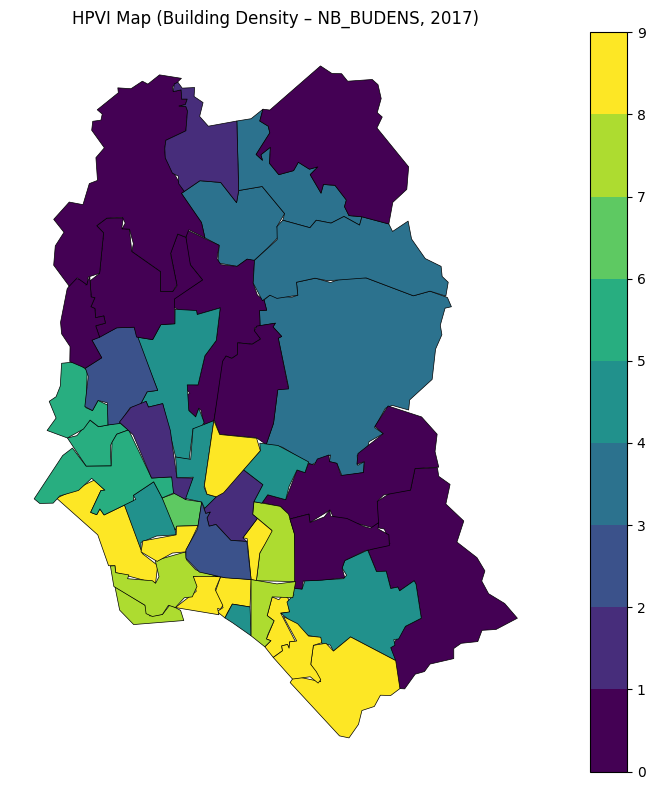

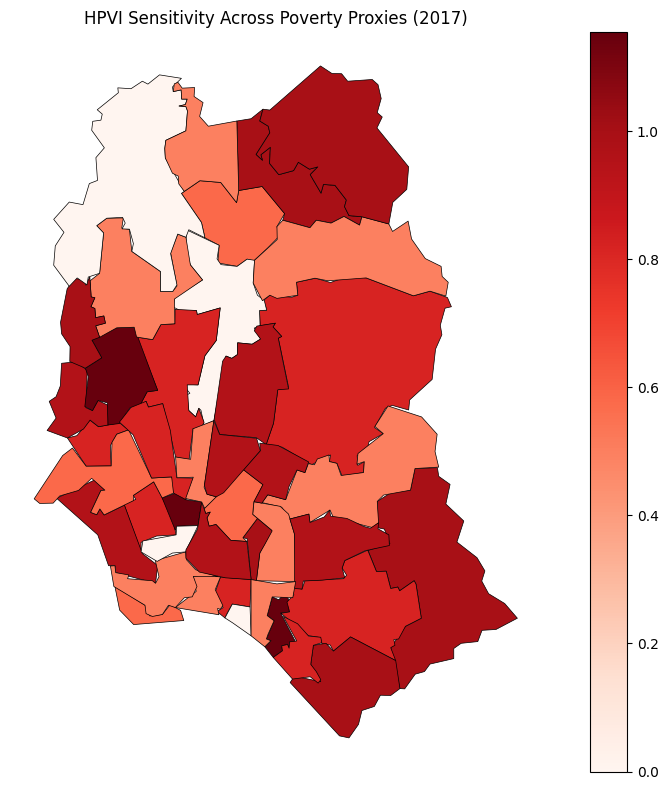

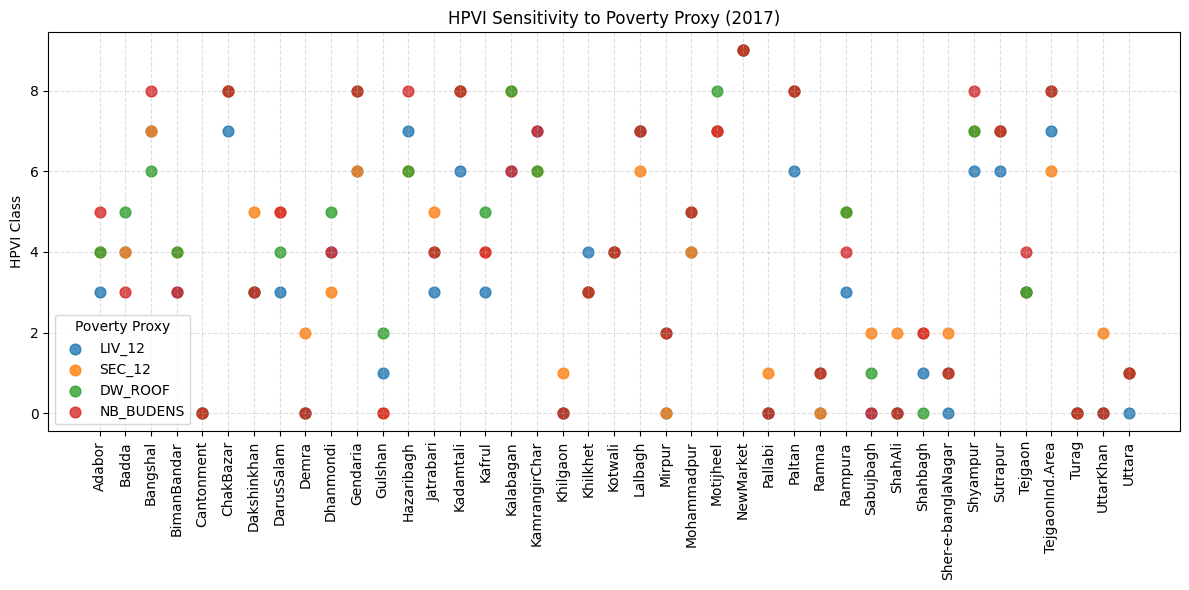

In [ ]:
# =====================================================
# Imports
# =====================================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Poverty proxies
# =====================================================
poverty_proxies = ["LIV_12", "SEC_12", "DW_ROOF", "NB_BUDENS"]

# =====================================================
# HPVI computation function
# =====================================================
def compute_hpvi(
    year,
    gdf,
    poverty_gdf,
    all_yearly_lst_data, # Renamed parameter from mean_lst_per_zone
    poverty_proxies,
    k=3
):
    """
    Compute HPVI classes for a given year and multiple poverty proxies.

    Returns
    -------
    hpvi_results : dict
        {proxy: DataFrame with ['Zone_Name', 'HPVI_class']}
    comparison_df : DataFrame
        Zone-wise HPVI classes across all proxies
    """

    # ----------------------------------------------
    # 1. Filter LST for selected year
    # ----------------------------------------------
    # Filter the full yearly data for the specified year
    mean_lst_year = all_yearly_lst_data[all_yearly_lst_data["Year"] == year][["Zone_Name", "CDI"]].copy()
    mean_lst_year.rename(columns={"CDI": "Mean_LST_Annual"}, inplace=True)

    hpvi_results = {}

    # ----------------------------------------------
    # 2. Loop over poverty proxies
    # ----------------------------------------------
    for proxy in poverty_proxies:
        print(f"Processing poverty proxy ({year}): {proxy}")

        if proxy not in poverty_gdf.columns:
            print(f"  Warning: {proxy} not found, skipping.")
            continue

        # Spatial join: poverty → zones
        poverty_joined = gpd.sjoin(
            poverty_gdf[[proxy, "geometry"]],
            gdf[["Zone_Name", "geometry"]],
            how="left",
            predicate="intersects"
        )

        # Zone-level poverty index
        poverty_zone = (
            poverty_joined
            .groupby("Zone_Name")[proxy]
            .mean()
            .reset_index()
            .rename(columns={proxy: "poverty_index"})
        )

        # Merge with LST
        hpvi_temp = (
            gdf
            .merge(mean_lst_year, on="Zone_Name", how="left")
            .merge(poverty_zone, on="Zone_Name", how="left")
        )

        # ------------------------------------------
        # Quantile classification
        # ------------------------------------------
        # Drop rows with NaN values in poverty_index or Mean_LST_Annual before quantile calculation
        hpvi_temp_filtered_for_quantiles = hpvi_temp.dropna(subset=["poverty_index", "Mean_LST_Annual"])

        if hpvi_temp_filtered_for_quantiles.empty:
            print(f"  Warning: No valid data for quantile calculation for {proxy} in {year}. Skipping HPVI calculation.")
            hpvi_temp["HPVI_class"] = np.nan # Assign NaN if no data for quantiles
        else:
            poverty_bins = hpvi_temp_filtered_for_quantiles["poverty_index"].quantile(
                np.linspace(0, 1, k + 1)
            ).values

            lst_bins = hpvi_temp_filtered_for_quantiles["Mean_LST_Annual"].quantile(
                np.linspace(0, 1, k + 1)
            ).values

            hpvi_temp["Pov_q"] = pd.cut(
                hpvi_temp["poverty_index"],
                bins=poverty_bins,
                labels=False,
                include_lowest=True,
                duplicates="drop"
            )

            hpvi_temp["LST_q"] = pd.cut(
                hpvi_temp["Mean_LST_Annual"],
                bins=lst_bins,
                labels=False,
                include_lowest=True,
                duplicates="drop"
            )

            # HPVI class (3 × 3 = 9)
            hpvi_temp["HPVI_class"] = hpvi_temp["LST_q"] * k + hpvi_temp["Pov_q"]

        # Assign NoData class for any remaining NaNs
        no_data_class = k * k
        hpvi_temp["HPVI_class"] = (
            hpvi_temp["HPVI_class"]
            .fillna(no_data_class)
            .astype(int)
        )

        hpvi_results[proxy] = hpvi_temp[
            ["Zone_Name", "HPVI_class"]
        ].copy()

    # ----------------------------------------------
    # 3. Sensitivity comparison DataFrame
    # ----------------------------------------------
    comparison_df = gdf[["Zone_Name"]].copy()

    for proxy, df_hpvi in hpvi_results.items():
        comparison_df = comparison_df.merge(
            df_hpvi.rename(
                columns={"HPVI_class": f"HPVI_class_{proxy}"}
            ),
            on="Zone_Name",
            how="left"
        )

    return hpvi_results, comparison_df

# =====================================================
# Run HPVI for 2017
# =====================================================
hpvi_results_2017, comparison_2017 = compute_hpvi(
    year=2017,
    gdf=gdf,
    poverty_gdf=poverty_gdf,
    all_yearly_lst_data=df_cdi, # Pass df_cdi here
    poverty_proxies=poverty_proxies,
    k=3
)

# =====================================================
# Sensitivity metric (standard deviation)
# =====================================================
comparison_2017["HPVI_sensitivity"] = (
    comparison_2017
    .filter(like="HPVI_class_")
    .std(axis=1)
)

# =====================================================
# Optional: Plot HPVI map (NB_BUDENS, 2017)
# =====================================================
gdf_hpvi_nb = gdf.merge(
    hpvi_results_2017["NB_BUDENS"],
    on="Zone_Name"
)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_hpvi_nb.plot(
    column="HPVI_class",
    cmap=plt.get_cmap("viridis", 9),
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)
ax.set_title("HPVI Map (Building Density – NB_BUDENS, 2017)")
ax.axis("off")
plt.tight_layout()
plt.show()

# =====================================================
# Optional: Plot sensitivity heatmap
# =====================================================
gdf_sens = gdf.merge(
    comparison_2017[["Zone_Name", "HPVI_sensitivity"]],
    on="Zone_Name"
)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_sens.plot(
    column="HPVI_sensitivity",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)
ax.set_title("HPVI Sensitivity Across Poverty Proxies (2017)")
ax.axis("off")
plt.tight_layout()
plt.show()
# =====================================================
# Scatter plot: HPVI sensitivity across poverty proxies
# =====================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_2017["Zone_Name"]))

for proxy in poverty_proxies:
    col = f"HPVI_class_{proxy}"
    if col in comparison_2017.columns:
        ax.scatter(
            x,
            comparison_2017[col],
            label=proxy,
            s=60,
            alpha=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(comparison_2017["Zone_Name"], rotation=90)
ax.set_ylabel("HPVI Class")
ax.set_title("HPVI Sensitivity to Poverty Proxy (2017)")
ax.legend(title="Poverty Proxy")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()




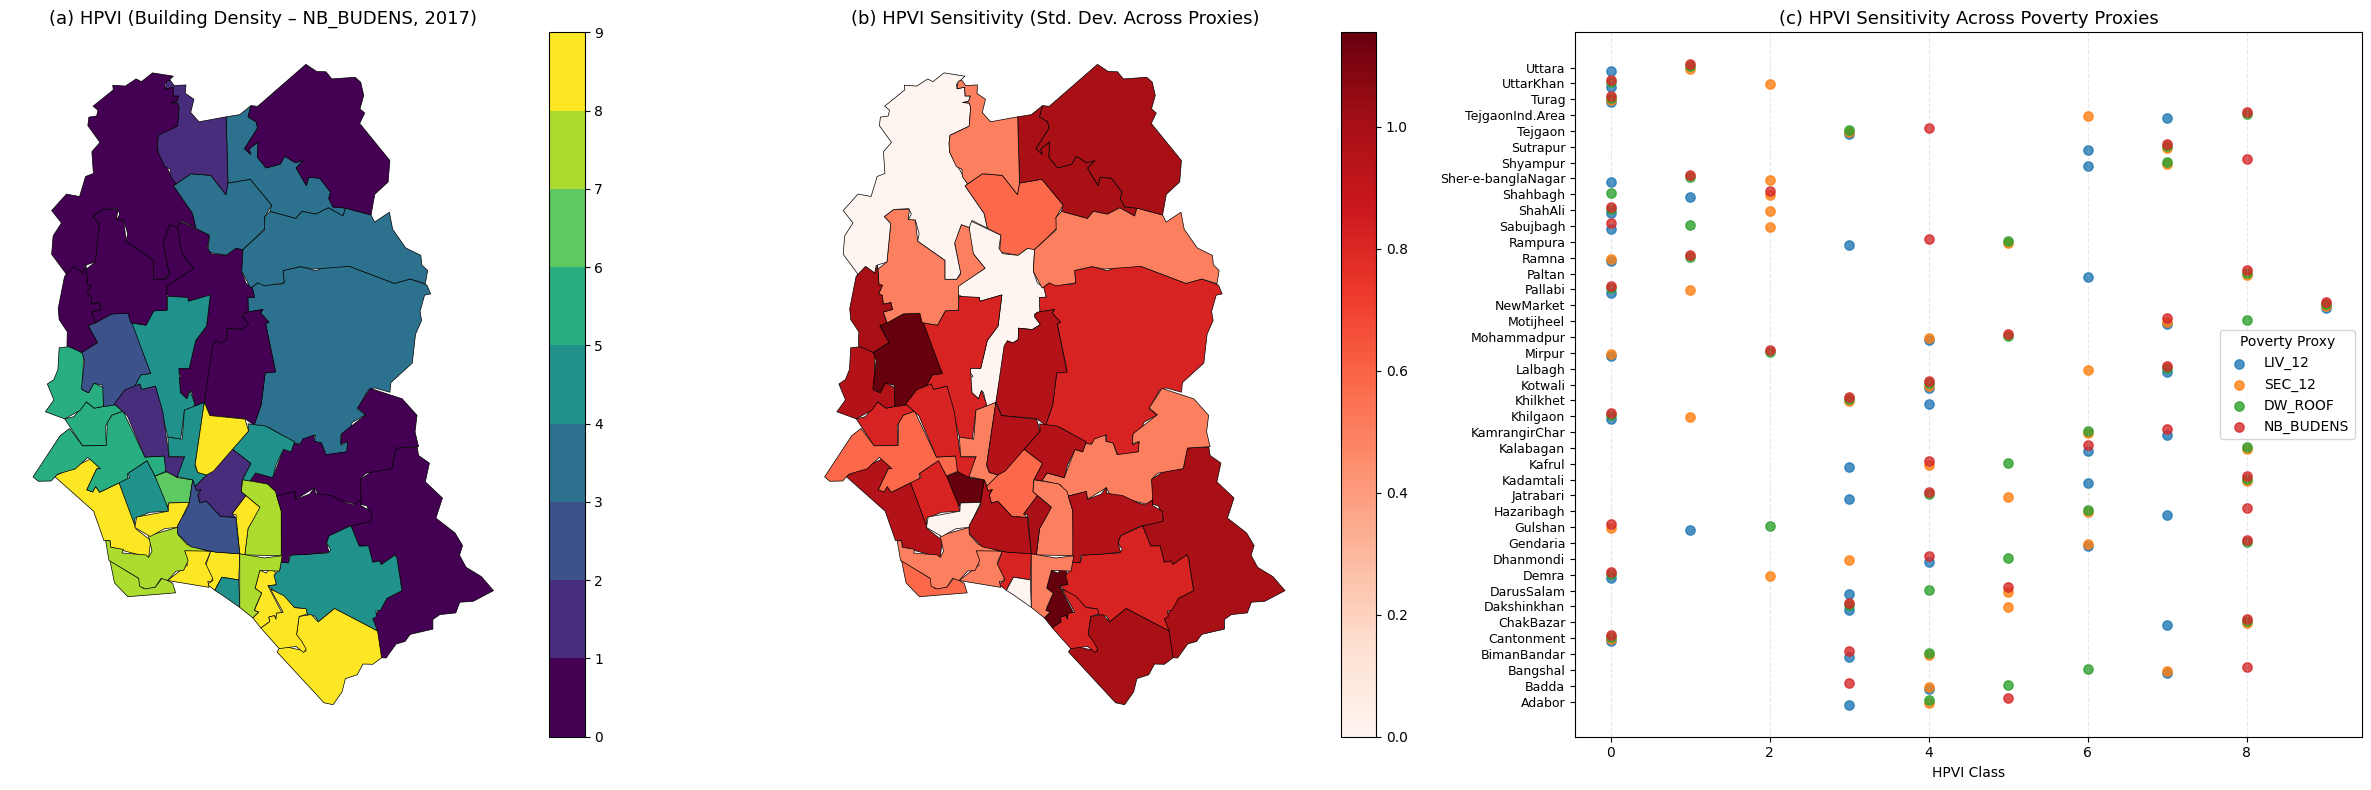

In [ ]:
# =====================================================
# Combined figure: 2 maps + 1 sensitivity plot
# =====================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={"width_ratios": [1, 1, 1.2]}
)

# -----------------------------------------------------
# (a) HPVI map — NB_BUDENS
# -----------------------------------------------------
gdf_hpvi_nb = gdf.merge(
    hpvi_results_2017["NB_BUDENS"],
    on="Zone_Name"
)

gdf_hpvi_nb.plot(
    column="HPVI_class",
    cmap=plt.get_cmap("viridis", 9),
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)

axes[0].set_title(
    "(a) HPVI (Building Density – NB_BUDENS, 2017)",
    fontsize=13
)
axes[0].axis("off")

# -----------------------------------------------------
# (b) HPVI sensitivity map (STD across proxies)
# -----------------------------------------------------
gdf_sens = gdf.merge(
    comparison_2017[["Zone_Name", "HPVI_sensitivity"]],
    on="Zone_Name"
)

gdf_sens.plot(
    column="HPVI_sensitivity",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)

axes[1].set_title(
    "(b) HPVI Sensitivity (Std. Dev. Across Proxies)",
    fontsize=13
)
axes[1].axis("off")

# -----------------------------------------------------
# (c) Sensitivity scatter plot
# -----------------------------------------------------
y = np.arange(len(comparison_2017["Zone_Name"]))
jitter = np.linspace(-0.2, 0.2, len(poverty_proxies))

for i, proxy in enumerate(poverty_proxies):
    col = f"HPVI_class_{proxy}"
    if col in comparison_2017.columns:
        axes[2].scatter(
            comparison_2017[col],
            y + jitter[i],
            label=proxy,
            s=45,
            alpha=0.8
        )

axes[2].set_yticks(y)
axes[2].set_yticklabels(
    comparison_2017["Zone_Name"],
    fontsize=9
)
axes[2].set_xlabel("HPVI Class")
axes[2].set_title(
    "(c) HPVI Sensitivity Across Poverty Proxies",
    fontsize=13
)
axes[2].legend(title="Poverty Proxy")
axes[2].grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


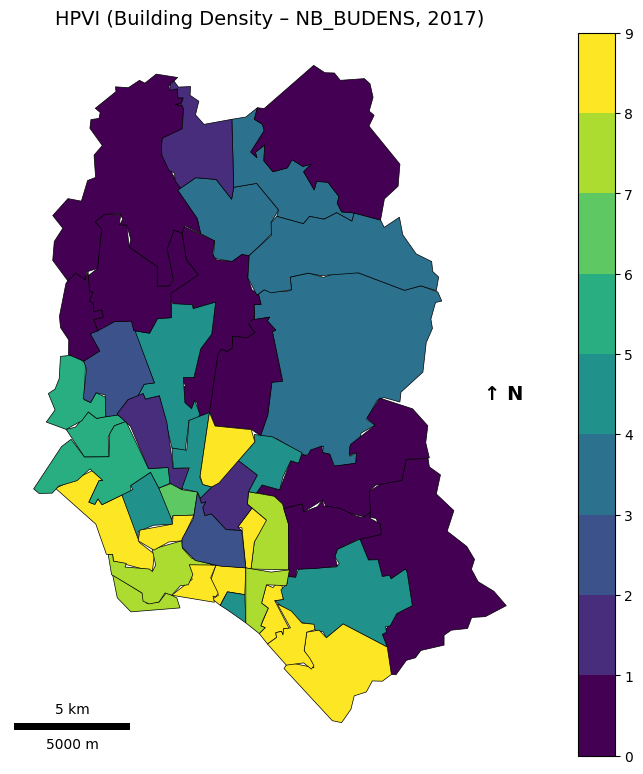

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# Merge HPVI results with zone geometry
gdf_hpvi_nb = gdf.merge(
    hpvi_results_2017["NB_BUDENS"],
    on="Zone_Name",
    how="left"
)

# Ensure CRS is in meters for scale bar
if gdf_hpvi_nb.crs.is_geographic:
    gdf_hpvi_nb = gdf_hpvi_nb.to_crs(epsg=3857)  # Web Mercator (meters)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot HPVI map
gdf_hpvi_nb.plot(
    column="HPVI_class",
    cmap=plt.get_cmap("viridis", 9),
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("HPVI (Building Density – NB_BUDENS, 2017)", fontsize=14)
ax.axis("off")

# -----------------------------
# Add 5 km Scale Bar
# -----------------------------
scalebar = ScaleBar(
    dx=1,          # 1 map unit = 1 meter (CRS in meters)
    units="m",
    length_fraction=0.15,  # fraction of map width
    location="lower left",
    scale_loc="bottom",
    label="5 km",
    fixed_value=5000       # 5 km
)
ax.add_artist(scalebar)

# -----------------------------
# Add North Arrow at center-right
# -----------------------------
x, y = 0.95, 0.5  # axes fraction (right center)
ax.annotate(
    '↑ N',
    xy=(x, y), xycoords='axes fraction',
    fontsize=14,
    ha='center',
    va='center',
    fontweight='bold'
)

plt.tight_layout()
plt.show()


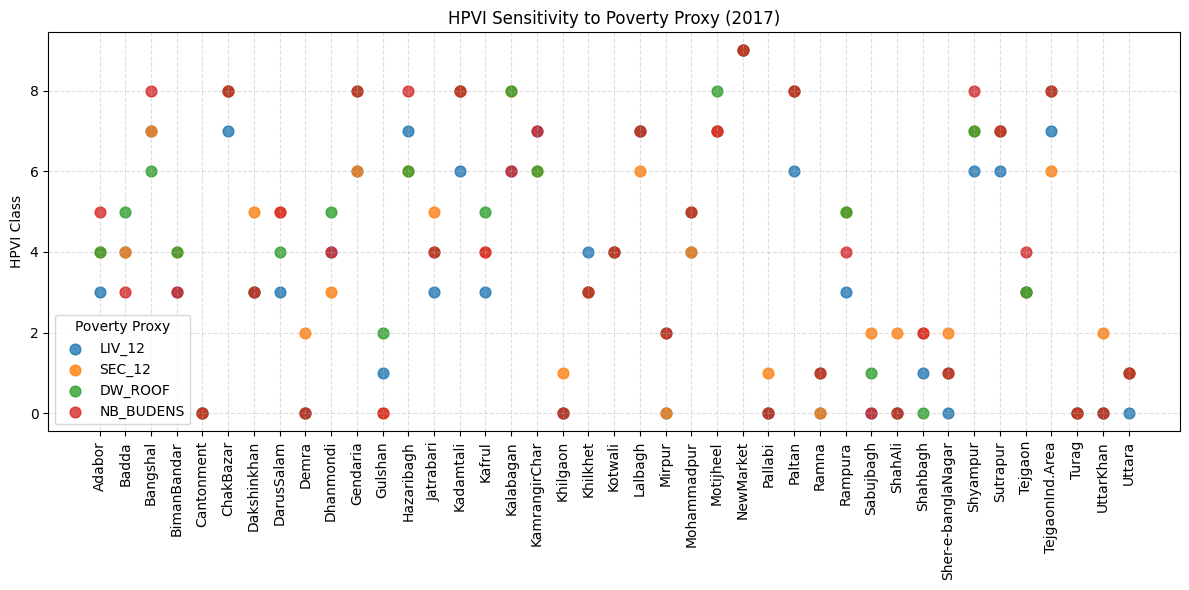

In [ ]:
# =====================================================
# Scatter plot: HPVI sensitivity across poverty proxies
# =====================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_2017["Zone_Name"]))

for proxy in poverty_proxies:
    col = f"HPVI_class_{proxy}"
    if col in comparison_2017.columns:
        ax.scatter(
            x,
            comparison_2017[col],
            label=proxy,
            s=60,
            alpha=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(comparison_2017["Zone_Name"], rotation=90)
ax.set_ylabel("HPVI Class")
ax.set_title("HPVI Sensitivity to Poverty Proxy (2017)")
ax.legend(title="Poverty Proxy")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


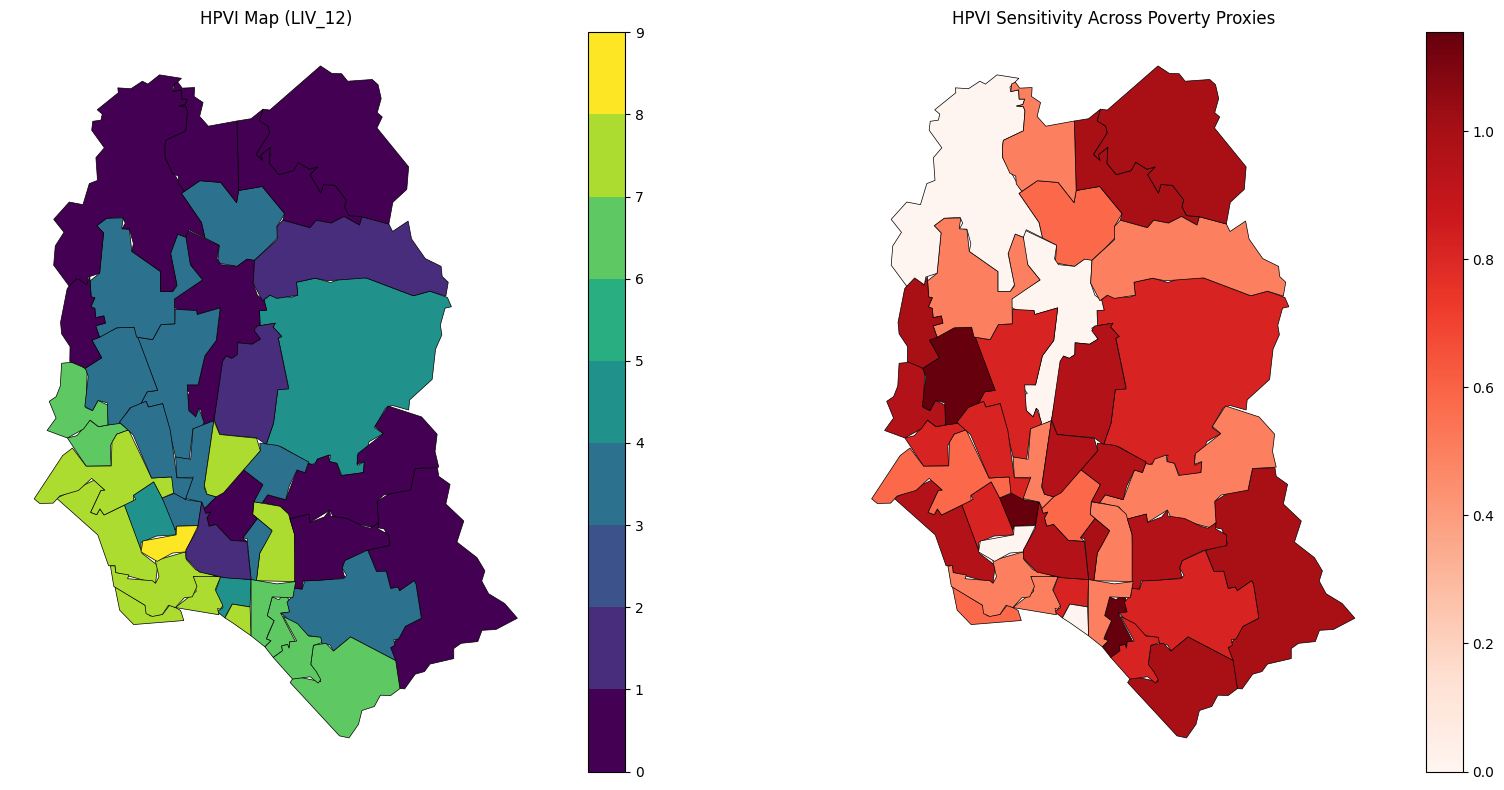

In [ ]:
# =====================================================
# 4. Create combined HPVI + sensitivity figure
# =====================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 4a. Choose main poverty proxy for original HPVI ----
main_proxy = "LIV_12"
hpvi_main = hpvi_results[main_proxy]

# Merge with gdf for plotting
gdf_hpvi = gdf.merge(hpvi_main, on="Zone_Name")

# ---- 4b. Compute HPVI sensitivity across proxies ----
hpvi_classes_df = comparison_df[[f"HPVI_class_{p}" for p in poverty_proxies]]
comparison_df["HPVI_sensitivity"] = hpvi_classes_df.std(axis=1)

gdf_sens = gdf.merge(comparison_df[["Zone_Name", "HPVI_sensitivity"]], on="Zone_Name")

# ---- 4c. Plot side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Original HPVI map
hpvi_cmap = plt.get_cmap("viridis", 9)  # 3x3 classes = 9
gdf_hpvi.plot(
    column="HPVI_class",
    cmap=hpvi_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)
axes[0].set_title(f"HPVI Map ({main_proxy})")
axes[0].axis("off")

# Sensitivity heatmap
sens_cmap = plt.get_cmap("Reds")
gdf_sens.plot(
    column="HPVI_sensitivity",
    cmap=sens_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("HPVI Sensitivity Across Poverty Proxies")
axes[1].axis("off")

plt.tight_layout()
plt.show()


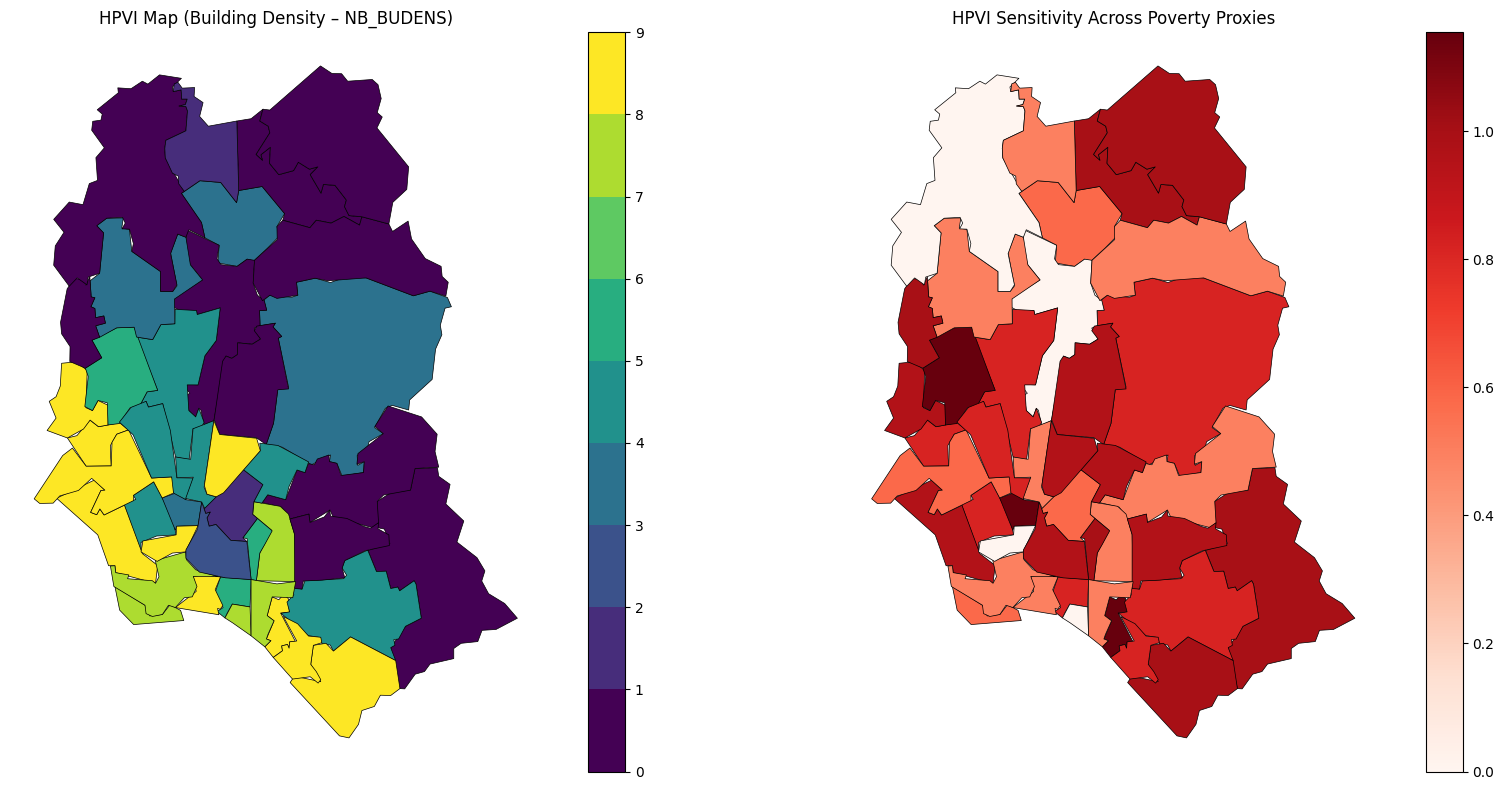

In [ ]:
# =====================================================
# 4. Create combined HPVI + sensitivity figure
#    (Building Density: NB_BUDENS)
# =====================================================
import matplotlib.pyplot as plt

# ---- 4a. Choose main poverty proxy ----
main_proxy = "NB_BUDENS"
hpvi_main = hpvi_results[main_proxy]

# Merge with gdf for plotting
gdf_hpvi = gdf.merge(hpvi_main, on="Zone_Name")

# ---- 4b. Compute HPVI sensitivity across proxies ----
hpvi_classes_df = comparison_df[[f"HPVI_class_{p}" for p in poverty_proxies]]
comparison_df["HPVI_sensitivity"] = hpvi_classes_df.std(axis=1)

gdf_sens = gdf.merge(
    comparison_df[["Zone_Name", "HPVI_sensitivity"]],
    on="Zone_Name"
)

# ---- 4c. Plot side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# HPVI map (NB_BUDENS)
hpvi_cmap = plt.get_cmap("viridis", 9)  # 3x3 classes
gdf_hpvi.plot(
    column="HPVI_class",
    cmap=hpvi_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)"HPVI Map (Building Density – NB_BUDENS)"
axes[0].set_title()
axes[0].axis("off")

# Sensitivity heatmap
sens_cmap = plt.get_cmap("Reds")
gdf_sens.plot(
    column="HPVI_sensitivity",
    cmap=sens_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("HPVI Sensitivity Across Poverty Proxies")
axes[1].axis("off")

plt.tight_layout()
plt.show()


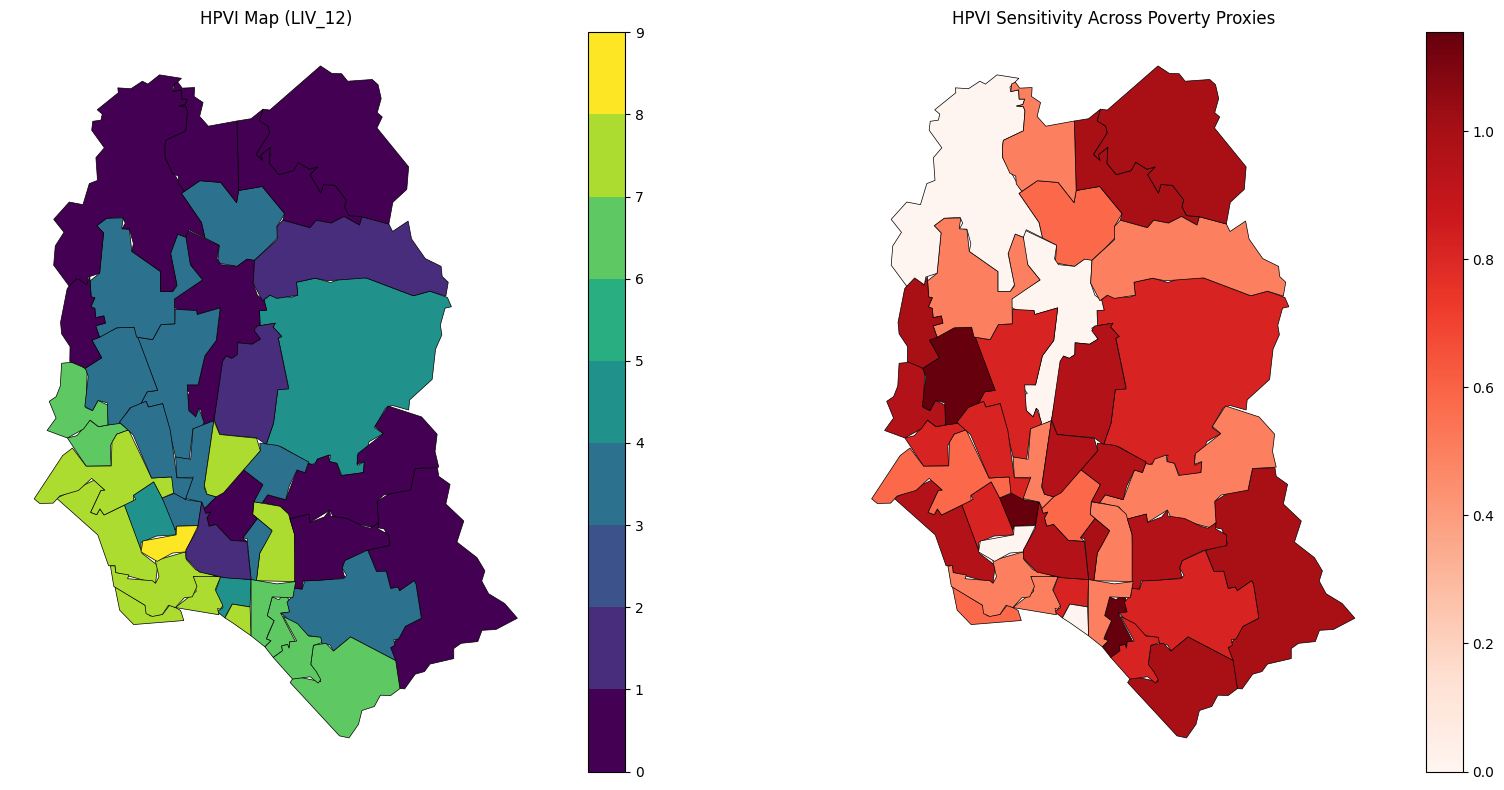

In [ ]:
# =====================================================
# Combined HPVI Map + Sensitivity Heatmap
# =====================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ---- 0. Ensure HPVI results are in correct format ----
# Rename HPVI_class columns to include proxy for comparison
comparison_df = gdf[["Zone_Name"]].copy()

for proxy, df_hpvi in hpvi_results.items():
    df_temp = df_hpvi.rename(columns={"HPVI_class": f"HPVI_class_{proxy}"})
    comparison_df = comparison_df.merge(df_temp, on="Zone_Name", how="left")

# ---- 1. Compute HPVI sensitivity (std across proxies) ----
hpvi_classes_df = comparison_df[[f"HPVI_class_{p}" for p in poverty_proxies]]
comparison_df["HPVI_sensitivity"] = hpvi_classes_df.std(axis=1)

# Merge HPVI & sensitivity back to spatial gdf
main_proxy = "LIV_12"
gdf_hpvi = gdf.merge(hpvi_results[main_proxy], on="Zone_Name")
gdf_sens = gdf.merge(comparison_df[["Zone_Name", "HPVI_sensitivity"]], on="Zone_Name")

# ---- 2. Plot side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 2a. Original HPVI map
hpvi_cmap = plt.get_cmap("viridis", 9)  # 3x3 classes = 9
gdf_hpvi.plot(
    column="HPVI_class",
    cmap=hpvi_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)
axes[0].set_title(f"HPVI Map ({main_proxy})")
axes[0].axis("off")

# 2b. HPVI sensitivity heatmap
sens_cmap = plt.get_cmap("Reds")
gdf_sens.plot(
    column="HPVI_sensitivity",
    cmap=sens_cmap,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("HPVI Sensitivity Across Poverty Proxies")
axes[1].axis("off")

plt.tight_layout()
plt.show()


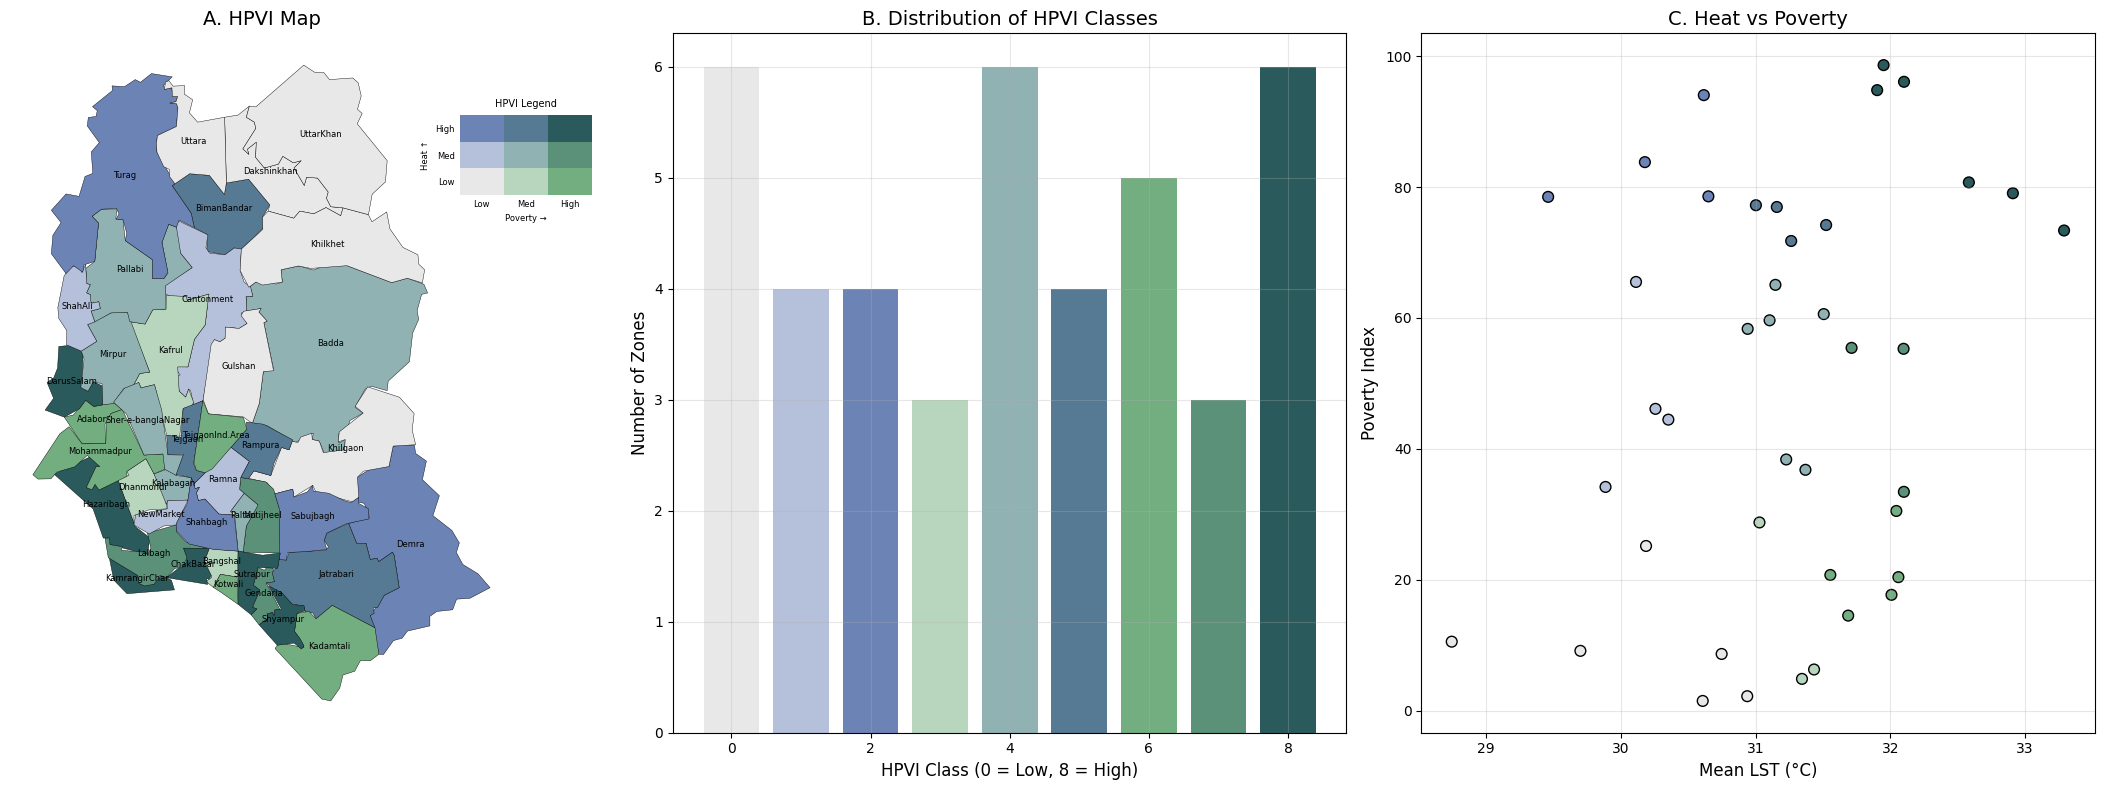

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# ---------------------------------------------------------
# 1. Prepare HPVI data (2017)
# ---------------------------------------------------------
hpvi = heat_poverty.copy()  # Must contain Mean_LST (2017) + poverty_rate
hpvi["centroid"] = hpvi.geometry.centroid

k = 3  # number of classes per variable

# Assuming poverty_col was defined as 'poverty_rate' in o8EguJGsx4qH
poverty_col_name = 'poverty_rate'

# Quantile bins for 2017 heat + 2017 poverty
poverty_bins = hpvi[poverty_col_name].quantile([i/k for i in range(k+1)]).values
lst_bins = hpvi["Mean_LST_Annual"].quantile([i/k for i in range(k+1)]).values

hpvi["Pov_q"] = pd.cut(hpvi[poverty_col_name], bins=poverty_bins, labels=False, include_lowest=True, duplicates='drop')
hpvi["LST_q"] = pd.cut(hpvi["Mean_LST_Annual"], bins=lst_bins, labels=False, include_lowest=True, duplicates='drop')

hpvi["HPVI_class"] = hpvi["LST_q"] * k + hpvi["Pov_q"]

# Bivariate color palette (same as CDI)
hpvi_colors = [
    "#e8e8e8", "#b5c0da", "#6c83b5",
    "#b8d6be", "#90b2b3", "#567994",
    "#73ae80", "#5a9178", "#2a5a5b"
]
hpvi["color"] = hpvi["HPVI_class"].map(dict(enumerate(hpvi_colors)))

# ---------------------------------------------------------
# 2. Create 3‑panel layout
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# ---------------------------------------------------------
# PANEL A — HPVI MAP
# ---------------------------------------------------------
ax1 = axes[0]
hpvi.plot(color=hpvi["color"], edgecolor="black", linewidth=0.3, ax=ax1)

for idx, row in hpvi.iterrows():
    ax1.text(row["centroid"].x, row["centroid"].y, row["Zone_Name"], fontsize=6, ha="center")

ax1.set_title("A. HPVI Map", fontsize=14)
ax1.axis("off")

# Add bivariate legend inside panel A (smaller and top-right)
legend_ax = fig.add_axes([0.25, 0.75, 0.06, 0.1]) # Adjusted position and size
legend_ax.set_xlim(0, k)
legend_ax.set_ylim(0, k)

for x in range(k):
    for y in range(k):
        legend_ax.add_patch(Rectangle((x, y), 1, 1, facecolor=hpvi_colors[x*k + y]))

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(["Low", "Med", "High"], fontsize=6) # Smaller font
legend_ax.set_yticklabels(["Low", "Med", "High"], fontsize=6) # Smaller font
legend_ax.set_xlabel("Poverty →", fontsize=6) # Smaller font
legend_ax.set_ylabel("Heat ↑", fontsize=6) # Smaller font
legend_ax.set_title("HPVI Legend", fontsize=7) # Smaller font
legend_ax.tick_params(length=0)
legend_ax.set_frame_on(False)

# ---------------------------------------------------------
# PANEL B — HPVI CLASS DISTRIBUTION
# ---------------------------------------------------------
ax2 = axes[1]

class_counts = hpvi["HPVI_class"].value_counts().sort_index()
ax2.bar(class_counts.index, class_counts.values, color=[hpvi_colors[i] for i in class_counts.index])

ax2.set_title("B. Distribution of HPVI Classes", fontsize=14)
ax2.set_xlabel("HPVI Class (0 = Low, 8 = High)", fontsize=12)
ax2.set_ylabel("Number of Zones", fontsize=12)
ax2.grid(alpha=0.3)

# ---------------------------------------------------------
# PANEL C — HEAT vs POVERTY SCATTER (2017)
# ---------------------------------------------------------
ax3 = axes[2]

ax3.scatter(
    hpvi["Mean_LST_Annual"],
    hpvi[poverty_col_name],
    c=hpvi["color"],
    edgecolor="black",
    s=60
)

ax3.set_title("C. Heat vs Poverty", fontsize=14)
ax3.set_xlabel("Mean LST (°C)", fontsize=12)
ax3.set_ylabel("Poverty Index", fontsize=12)
ax3.grid(alpha=0.3)

# ---------------------------------------------------------
# Final layout
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

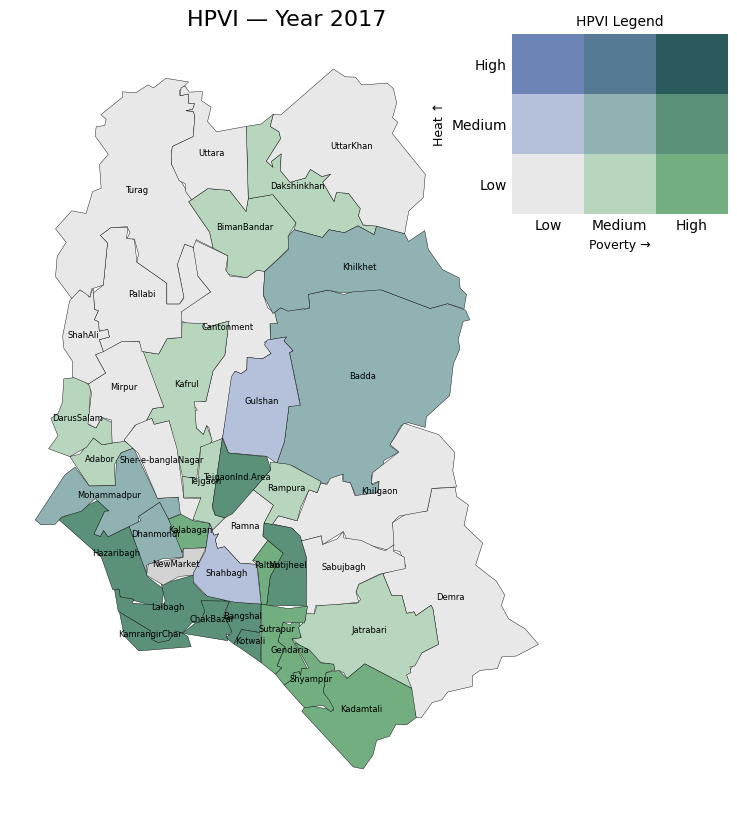

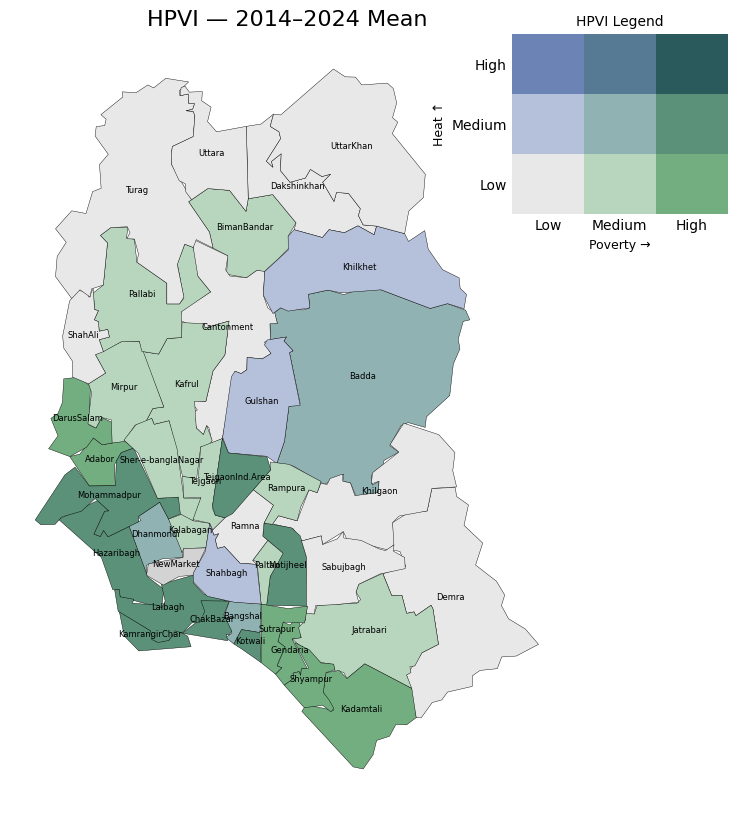

In [ ]:
# =====================================================
# 0. Imports
# =====================================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# =====================================================
# 1. Poverty GeoDataFrame (already extracted from EE)
# =====================================================
poverty_geojson = poverty_ee.getInfo()
poverty_gdf = gpd.GeoDataFrame.from_features(poverty_geojson["features"])
poverty_gdf.crs = "EPSG:4326"
poverty_gdf = poverty_gdf.to_crs(gdf.crs)

poverty_value_col = "LIV_12"

# =====================================================
# 2. Function to compute HPVI for any year or period
# =====================================================
def compute_hpvi(gdf, df_cdi_subset, poverty_gdf, poverty_value_col="LIV_12", k=3):

    # ---- Poverty aggregated to zones ----
    poverty_joined = gpd.sjoin(
        poverty_gdf[[poverty_value_col, "geometry"]],
        gdf[["Zone_Name", "geometry"]],
        how="left",
        predicate="intersects"
    )

    poverty_zone = (
        poverty_joined
        .groupby("Zone_Name")[poverty_value_col]
        .mean()
        .reset_index()
    )

    # ---- Mean CDI for this year/period ----
    mean_lst_per_zone = (
        df_cdi_subset.groupby("Zone_Name")["CDI"]
        .mean()
        .reset_index()
        .rename(columns={"CDI": "Mean_LST_Annual"})
    )

    # ---- Build HPVI GeoDataFrame ----
    hpvi = (
        gdf
        .merge(mean_lst_per_zone, on="Zone_Name", how="left")
        .merge(poverty_zone, on="Zone_Name", how="left")
    )

    hpvi["centroid"] = hpvi.geometry.centroid

    # ---- Quantile bins ----
    poverty_bins = hpvi[poverty_value_col].quantile(np.linspace(0, 1, k + 1)).values
    lst_bins = hpvi["Mean_LST_Annual"].quantile(np.linspace(0, 1, k + 1)).values

    hpvi["Pov_q"] = pd.cut(
        hpvi[poverty_value_col],
        bins=poverty_bins,
        labels=False,
        include_lowest=True,
        duplicates="drop"
    )

    hpvi["LST_q"] = pd.cut(
        hpvi["Mean_LST_Annual"],
        bins=lst_bins,
        labels=False,
        include_lowest=True,
        duplicates="drop"
    )

    hpvi["HPVI_class"] = hpvi["LST_q"] * k + hpvi["Pov_q"]
    hpvi["HPVI_class"] = hpvi["HPVI_class"].fillna(k*k).astype(int)

    return hpvi

# =====================================================
# 3. Plotting function
# =====================================================
def plot_hpvi(hpvi, title):
    fig, ax = plt.subplots(figsize=(12, 10))

    hpvi_colors = [
        "#e8e8e8", "#b5c0da", "#6c83b5",
        "#b8d6be", "#90b2b3", "#567994",
        "#73ae80", "#5a9178", "#2a5a5b"
    ]
    hpvi_colors_extended = hpvi_colors + ["#d3d3d3"]

    hpvi["color"] = hpvi["HPVI_class"].map(dict(enumerate(hpvi_colors_extended)))

    hpvi.plot(color=hpvi["color"], edgecolor="black", linewidth=0.3, ax=ax)

    for _, row in hpvi.iterrows():
        ax.text(row.centroid.x, row.centroid.y, row["Zone_Name"], fontsize=6, ha="center")

    ax.set_title(title, fontsize=16)
    ax.axis("off")

    # ---- Bivariate legend ----
    k = 3
    legend_ax = fig.add_axes([0.7, 0.7, 0.18, 0.18])
    legend_ax.set_xlim(0, k)
    legend_ax.set_ylim(0, k)

    for x in range(k):
        for y in range(k):
            legend_ax.add_patch(Rectangle((x, y), 1, 1, facecolor=hpvi_colors[x * k + y]))

    legend_ax.set_xticks([0.5, 1.5, 2.5])
    legend_ax.set_yticks([0.5, 1.5, 2.5])
    legend_ax.set_xticklabels(["Low", "Medium", "High"])
    legend_ax.set_yticklabels(["Low", "Medium", "High"])
    legend_ax.set_xlabel("Poverty →", fontsize=9)
    legend_ax.set_ylabel("Heat ↑", fontsize=9)
    legend_ax.set_title("HPVI Legend", fontsize=10)
    legend_ax.tick_params(length=0)
    legend_ax.set_frame_on(False)

    plt.show()

# =====================================================
# 4. Compute HPVI for 2017
# =====================================================
df_cdi_2017 = df_cdi[df_cdi["Year"] == 2017]

hpvi_2017 = compute_hpvi(gdf, df_cdi_2017, poverty_gdf)
plot_hpvi(hpvi_2017, "HPVI — Year 2017")

# =====================================================
# 5. Compute HPVI for 2014–2024 (multi-year mean)
# =====================================================
df_cdi_2014_2024 = df_cdi[(df_cdi["Year"] >= 2014) & (df_cdi["Year"] <= 2024)]

hpvi_2014_2024 = compute_hpvi(gdf, df_cdi_2014_2024, poverty_gdf)
plot_hpvi(hpvi_2014_2024, "HPVI — 2014–2024 Mean")


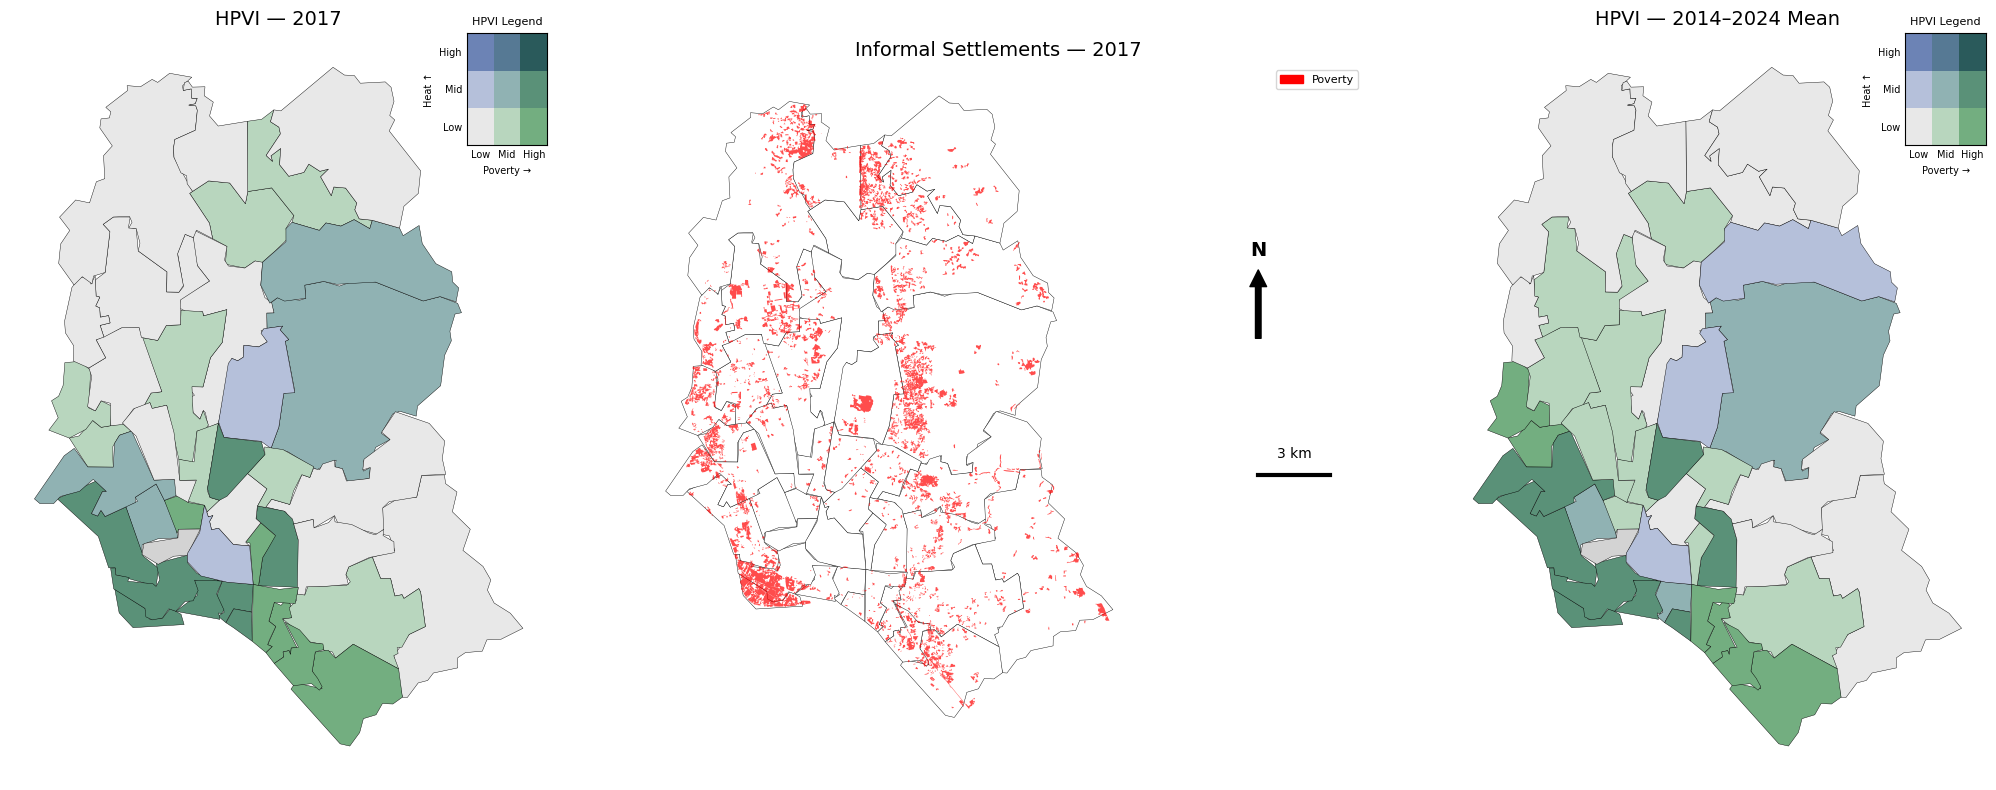

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import numpy as np
import ee

# =====================================================
# 1. Poverty GeoDataFrame from Earth Engine
# =====================================================
poverty_geojson = poverty_ee.getInfo()
poverty_gdf = gpd.GeoDataFrame.from_features(poverty_geojson["features"])
poverty_gdf.crs = "EPSG:4326"

# =====================================================
# 2. Informal Settlements 2017
# =====================================================
informal_ee = ee.FeatureCollection("projects/ee-sanim/assets/eo4sd_dhaka_informal_2017")
informal_geojson = informal_ee.getInfo()
informal_gdf = gpd.GeoDataFrame.from_features(informal_geojson["features"])
informal_gdf.crs = "EPSG:4326"

# =====================================================
# 3. Reproject all layers to UTM Zone 46N (meters)
# =====================================================
target_crs = "EPSG:32646"

gdf = gdf.to_crs(target_crs)
poverty_gdf = poverty_gdf.to_crs(target_crs)
informal_gdf = informal_gdf.to_crs(target_crs)

poverty_value_col = "LIV_12"

# =====================================================
# 4. HPVI computation function
# =====================================================
def compute_hpvi(gdf, df_cdi_subset, poverty_gdf, poverty_value_col="LIV_12", k=3):

    poverty_joined = gpd.sjoin(
        poverty_gdf[[poverty_value_col, "geometry"]],
        gdf[["Zone_Name", "geometry"]],
        how="left",
        predicate="intersects"
    )

    poverty_zone = (
        poverty_joined
        .groupby("Zone_Name")[poverty_value_col]
        .mean()
        .reset_index()
    )

    mean_lst_per_zone = (
        df_cdi_subset.groupby("Zone_Name")["CDI"]
        .mean()
        .reset_index()
        .rename(columns={"CDI": "Mean_LST_Annual"})
    )

    hpvi = (
        gdf
        .merge(mean_lst_per_zone, on="Zone_Name", how="left")
        .merge(poverty_zone, on="Zone_Name", how="left")
    )

    hpvi["centroid"] = hpvi.geometry.centroid

    poverty_bins = hpvi[poverty_value_col].quantile(np.linspace(0, 1, k + 1)).values
    lst_bins = hpvi["Mean_LST_Annual"].quantile(np.linspace(0, 1, k + 1)).values

    hpvi["Pov_q"] = pd.cut(
        hpvi[poverty_value_col], bins=poverty_bins,
        labels=False, include_lowest=True, duplicates="drop"
    )

    hpvi["LST_q"] = pd.cut(
        hpvi["Mean_LST_Annual"], bins=lst_bins,
        labels=False, include_lowest=True, duplicates="drop"
    )

    hpvi["HPVI_class"] = hpvi["LST_q"] * k + hpvi["Pov_q"]
    hpvi["HPVI_class"] = hpvi["HPVI_class"].fillna(k*k).astype(int)

    return hpvi

# =====================================================
# 5. Prepare CDI subsets
# =====================================================
df_cdi_2017 = df_cdi[df_cdi["Year"] == 2017]
df_cdi_2014_2024 = df_cdi[(df_cdi["Year"] >= 2014) & (df_cdi["Year"] <= 2024)]

hpvi_2017 = compute_hpvi(gdf, df_cdi_2017, poverty_gdf)
hpvi_2014_2024 = compute_hpvi(gdf, df_cdi_2014_2024, poverty_gdf)

# =====================================================
# 6. HPVI color scheme
# =====================================================
hpvi_colors = [
    "#e8e8e8", "#b5c0da", "#6c83b5",
    "#b8d6be", "#90b2b3", "#567994",
    "#73ae80", "#5a9178", "#2a5a5b"
]
hpvi_colors_extended = hpvi_colors + ["#d3d3d3"]

hpvi_2017["color"] = hpvi_2017["HPVI_class"].map(dict(enumerate(hpvi_colors_extended)))
hpvi_2014_2024["color"] = hpvi_2014_2024["HPVI_class"].map(dict(enumerate(hpvi_colors_extended)))

# Poverty discrete colors (Low / Medium / High)
poverty_discrete_colors = ["#e8e8e8", "#b5c0da", "#6c83b5"]

# =====================================================
# 7. HPVI legend (3×3 grid, with Low/Mid/High labels) - MODIFIED
# =====================================================
def add_small_hpvi_legend(ax, colors, k=3, size=0.15, pos=(0.85, 0.85), title="HPVI Legend"):
    inset = ax.inset_axes([pos[0], pos[1], size, size])
    inset.set_xlim(0, k)
    inset.set_ylim(0, k)

    for x in range(k):
        for y in range(k):
            inset.add_patch(Rectangle((x, y), 1, 1, facecolor=colors[x * k + y]))

    # Set tick labels for Low, Medium, High
    tick_labels = ["Low", "Mid", "High"]
    inset.set_xticks([0.5, 1.5, 2.5])
    inset.set_xticklabels(tick_labels, fontsize=7)
    inset.set_yticks([0.5, 1.5, 2.5])
    inset.set_yticklabels(tick_labels, fontsize=7)

    inset.set_xlabel("Poverty →", fontsize=7)
    inset.set_ylabel("Heat ↑", fontsize=7)
    inset.set_title(title, fontsize=8)
    inset.tick_params(length=0)
    inset.set_frame_on(True)

    return inset

# =====================================================
# 8. Global scale bar + north arrow
# =====================================================
def add_global_scalebar(fig, ax, length_km=3, pos=(0.50, 0.05)):
    length_m = length_km * 1000
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x = x_min + (x_max - x_min) * pos[0]
    y = y_min + (y_max - y_min) * pos[1]

    ax.plot([x, x + length_m], [y, y], color='black', linewidth=3)
    ax.text(x + length_m / 2, y + (y_max - y_min) * 0.02,
            f"{length_km} km", ha='center', va='bottom', fontsize=10)

def add_global_north_arrow(fig, ax, size=0.10, pos=(0.50, 0.15)):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x = x_min + (x_max - x_min) * pos[0]
    y = y_min + (y_max - y_min) * pos[1]

    arrow_length = (y_max - y_min) * size

    ax.annotate('', xy=(x, y + arrow_length), xytext=(x, y),
                arrowprops=dict(facecolor='black', width=4, headwidth=12))

    ax.text(x, y + arrow_length * 1.15, 'N',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# =====================================================
# 9. Three-panel figure
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Panel 1: HPVI 2017
hpvi_2017.plot(color=hpvi_2017["color"], edgecolor="black", linewidth=0.3, ax=axes[0])
axes[0].set_title("HPVI — 2017", fontsize=14)
axes[0].axis("off")
add_small_hpvi_legend(axes[0], hpvi_colors, pos=(0.85, 0.85), size=0.15)

# Panel 2: Informal Settlements 2017
gdf.plot(ax=axes[1], color="white", edgecolor="black", linewidth=0.3)
informal_gdf.plot(ax=axes[1], color="red", alpha=0.7, label="Poverty")
axes[1].set_title("Informal Settlements — 2017", fontsize=14)
axes[1].axis("off")
# Add legend for informal settlements
red_patch = Patch(color='red', label='Poverty')
axes[1].legend(handles=[red_patch], loc='upper right', fontsize=8)

# Panel 3: HPVI 2014–2024
hpvi_2014_2024.plot(color=hpvi_2014_2024["color"], edgecolor="black", linewidth=0.3, ax=axes[2])
axes[2].set_title("HPVI — 2014–2024 Mean", fontsize=14)
axes[2].axis("off")
add_small_hpvi_legend(axes[2], hpvi_colors, pos=(0.85, 0.85), size=0.15)

# =====================================================
# 10. Poverty Legend (Removed as per user request)
# =====================================================
# Removed the poverty legend block.

# =====================================================
# 11. Add ONE scale bar + ONE north arrow (between 2nd & 3rd panels)
# =====================================================
add_global_north_arrow(fig, axes[1], size=0.10, pos=(1.25, 0.60))
add_global_scalebar(fig, axes[1], length_km=3, pos=(1.25, 0.40))

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import io

# Your data as a multiline string
data_string = """
Zone,LST_mean,NB_BUDENS
Mirpur-1,34.2,0.78
Gulshan-2,31.1,0.22
"""

# Read the string data into a pandas DataFrame
df_example_data = pd.read_csv(io.StringIO(data_string))

# Display the DataFrame
print(df_example_data.head())

        Zone  LST_mean  NB_BUDENS
0   Mirpur-1      34.2       0.78
1  Gulshan-2      31.1       0.22


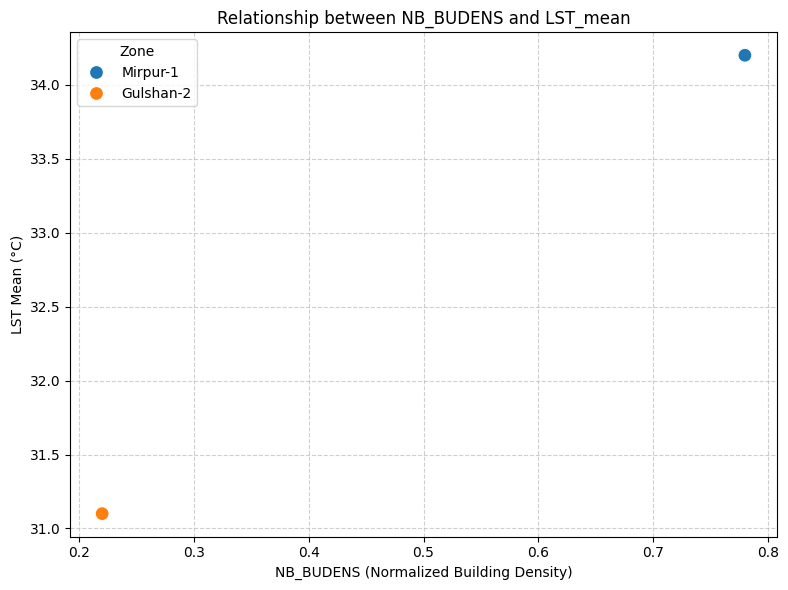

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='NB_BUDENS', y='LST_mean', data=df_example_data, s=100, hue='Zone', legend='full')
plt.title('Relationship between NB_BUDENS and LST_mean')
plt.xlabel('NB_BUDENS (Normalized Building Density)')
plt.ylabel('LST Mean (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the correlation coefficient
correlation = df_example_data['NB_BUDENS'].corr(df_example_data['LST_mean'])
print(f"Pearson correlation between NB_BUDENS and LST_mean: {correlation:.2f}")

Pearson correlation between NB_BUDENS and LST_mean: 1.00


In [ ]:
import pandas as pd

# Use the example DataFrame created previously for demonstration
df = df_example_data.copy() # Use .copy() to avoid modifying the original df_example_data
# The dataset must contain: Zone, LST_mean, NB_BUDENS

# Sort wards by poverty level (NB_BUDENS)
df_sorted = df.sort_values("NB_BUDENS", ascending=False)

# Define poverty groups (top 25% = high poverty, bottom 25% = low poverty)
# Ensure there's enough data for quantile calculation
if len(df) < 4: # Need at least 4 entries to have a top/bottom 25% for 2 entries each
    print("Not enough data in the DataFrame for 25% quantile analysis. Using full dataset.")
    high_poverty_group = df_sorted
    low_poverty_group = df_sorted
else:
    q25 = int(len(df) * 0.25)
    high_poverty_group = df_sorted.head(q25)
    low_poverty_group = df_sorted.tail(q25)

# Calculate group means
high_mean = high_poverty_group["LST_mean"].mean()
low_mean = low_poverty_group["LST_mean"].mean()

# Temperature difference
temp_diff = high_mean - low_mean

# Create summary table
summary = pd.DataFrame({
    "Group": ["High Poverty (Top 25%)", "Low Poverty (Bottom 25%)", "Difference"],
    "Mean LST (°C)": [high_mean, low_mean, temp_diff]
})

print(summary)

Not enough data in the DataFrame for 25% quantile analysis. Using full dataset.
                      Group  Mean LST (°C)
0    High Poverty (Top 25%)          32.65
1  Low Poverty (Bottom 25%)          32.65
2                Difference           0.00


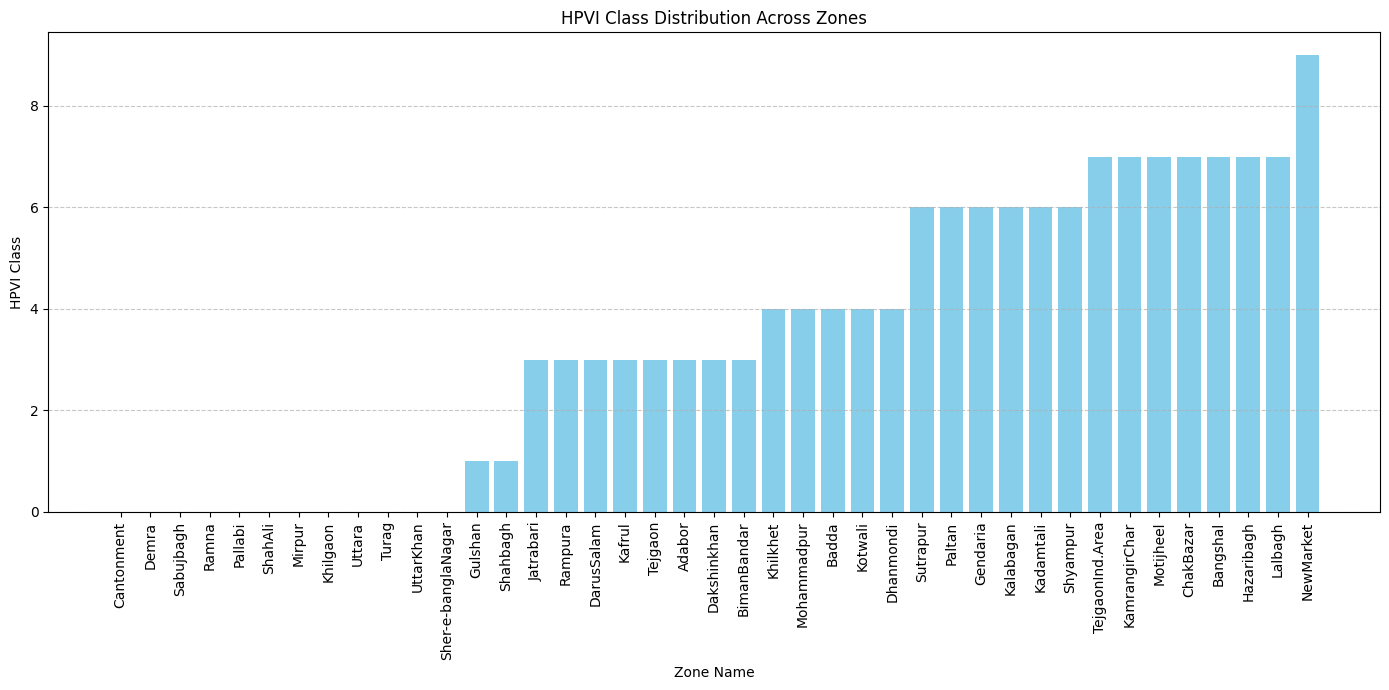

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming gdf_hpvi is available from previous steps
# If gdf_hpvi was not explicitly created, I will use hpvi_main and merge with gdf
# For robustness, let's ensure gdf_hpvi is correctly defined using main_proxy
if 'gdf_hpvi' not in locals():
    main_proxy = "LIV_12" # Or any other main proxy used in previous HPVI maps
    hpvi_main = hpvi_results_2017[main_proxy]
    gdf_hpvi = gdf.merge(hpvi_main, on="Zone_Name")

# Create a DataFrame for plotting
plot_df = gdf_hpvi[['Zone_Name', 'HPVI_class']].sort_values('HPVI_class')

plt.figure(figsize=(14, 7))
plt.bar(plot_df['Zone_Name'], plot_df['HPVI_class'], color='skyblue')
plt.xlabel('Zone Name')
plt.ylabel('HPVI Class')
plt.title('HPVI Class Distribution Across Zones')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
LST_FOLDER = "/content/drive/MyDrive/LST_2014_2024"

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

# Load the LST data (this DataFrame has 'NAME_3' for zones and 'mean' for LST)
df_lst = pd.read_csv("/content/dhaka_LST_2014_2024.csv")

# Rename 'NAME_3' to 'Zone_Name' to match 'poverty_zone' dataframe
df_lst = df_lst.rename(columns={'NAME_3': 'Zone_Name'})

# Calculate the mean LST across years for each zone for this analysis
# If you need year-specific analysis, this part would be different.
mean_lst_per_zone = df_lst.groupby('Zone_Name')['mean'].mean().reset_index()
mean_lst_per_zone = mean_lst_per_zone.rename(columns={'mean': 'LST_mean'})

# Merge LST data with poverty_zone (assuming poverty_zone has 'Zone_Name' and 'poverty_index')
# poverty_zone was calculated in a previous step (e.g., cell 'Pnx3tEnq6BW6')
# For this analysis, we will use the 'poverty_index' as the poverty proxy.
# If poverty_zone is not defined, you would need to run the relevant cell first (e.g., Pnx3tEnq6BW6).
df_merged = mean_lst_per_zone.merge(poverty_zone, on='Zone_Name', how='left')

# Drop rows where poverty_index is NaN (zones without poverty data)
df_merged = df_merged.dropna(subset=['poverty_index'])

# Sort wards by poverty level (using 'poverty_index')
df_sorted = df_merged.sort_values("poverty_index", ascending=False)

# Define poverty groups (top 25% = high poverty, bottom 25% = low poverty)
# Ensure there is enough data for quantile calculation
if len(df_sorted) < 4:
    print("Not enough data in the DataFrame for 25% quantile analysis. Using full dataset.")
    high_poverty_group = df_sorted
    low_poverty_group = df_sorted
else:
    q25 = max(1, int(len(df_sorted) * 0.25)) # Ensure at least 1 zone per group if possible
    high_poverty_group = df_sorted.head(q25)
    low_poverty_group = df_sorted.tail(q25)

# Extract LST values for the groups
high_lst = high_poverty_group["LST_mean"]
low_lst = low_poverty_group["LST_mean"]

# Check if groups are empty or have single values, for t-test.
if len(high_lst) < 2 or len(low_lst) < 2:
    print("Cannot perform t-test or Mann-Whitney U test due to insufficient data in groups.")
    print(f"High-poverty group size: {len(high_lst)}")
    print(f"Low-poverty group size: {len(low_lst)}")
    t_stat, t_p = float('nan'), float('nan')
    u_stat, u_p = float('nan'), float('nan')
else:
    # Independent t-test (parametric)
    t_stat, t_p = ttest_ind(high_lst, low_lst, equal_var=False)

    # Mann–Whitney U test (non-parametric)
    u_stat, u_p = mannwhitneyu(high_lst, low_lst, alternative="two-sided")

# Print results
print("High-poverty mean LST:", high_lst.mean())
print("Low-poverty mean LST:", low_lst.mean())
print("Temperature difference:", high_lst.mean() - low_lst.mean(), "°C\n")

print("T-test: t =", t_stat, ", p =", t_p)
print("Mann–Whitney U: U =", u_stat, ", p =", u_p)

High-poverty mean LST: 30.302610861450667
Low-poverty mean LST: 29.3161704686495
Temperature difference: 0.9864403928011676 °C

T-test: t = 4.245352392727405 , p = 0.0005027295957337089
Mann–Whitney U: U = 91.0 , p = 0.0022022199424970783


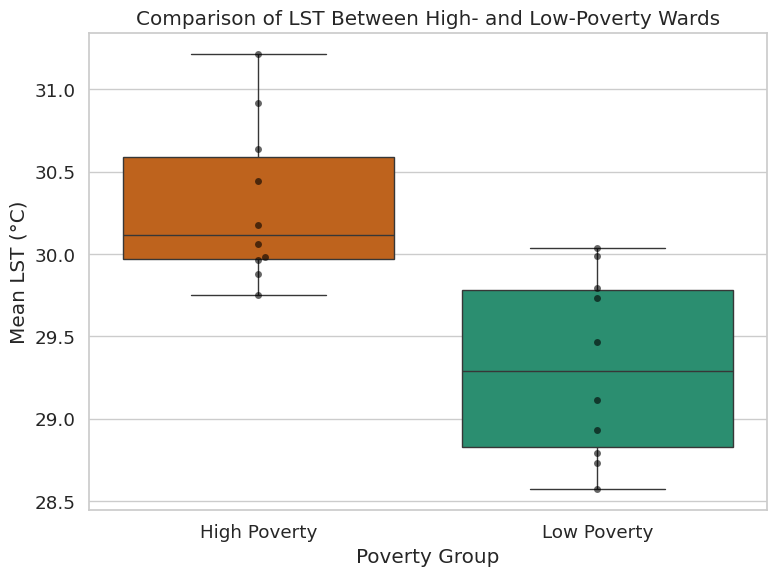

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a combined DataFrame for plotting
plot_df = pd.DataFrame({
    "LST_mean": list(high_lst) + list(low_lst),
    "Group": (["High Poverty"] * len(high_lst)) + (["Low Poverty"] * len(low_lst))
})

# Set style
sns.set(style="whitegrid", font_scale=1.2)

# Create the figure
plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="Group", y="LST_mean", palette=["#d95f02", "#1b9e77"])
sns.swarmplot(data=plot_df, x="Group", y="LST_mean", color="black", alpha=0.6)

# Labels and title
plt.title("Comparison of LST Between High- and Low-Poverty Wards")
plt.xlabel("Poverty Group")
plt.ylabel("Mean LST (°C)")

# Show plot
plt.tight_layout()
plt.show()


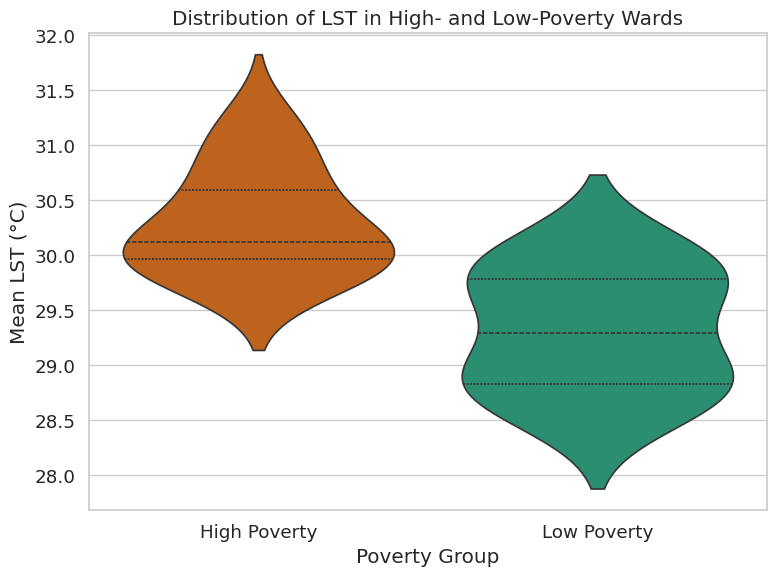

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=plot_df, x="Group", y="LST_mean", palette=["#d95f02", "#1b9e77"], inner="quartile")

plt.title("Distribution of LST in High- and Low-Poverty Wards")
plt.xlabel("Poverty Group")
plt.ylabel("Mean LST (°C)")

plt.tight_layout()
plt.show()


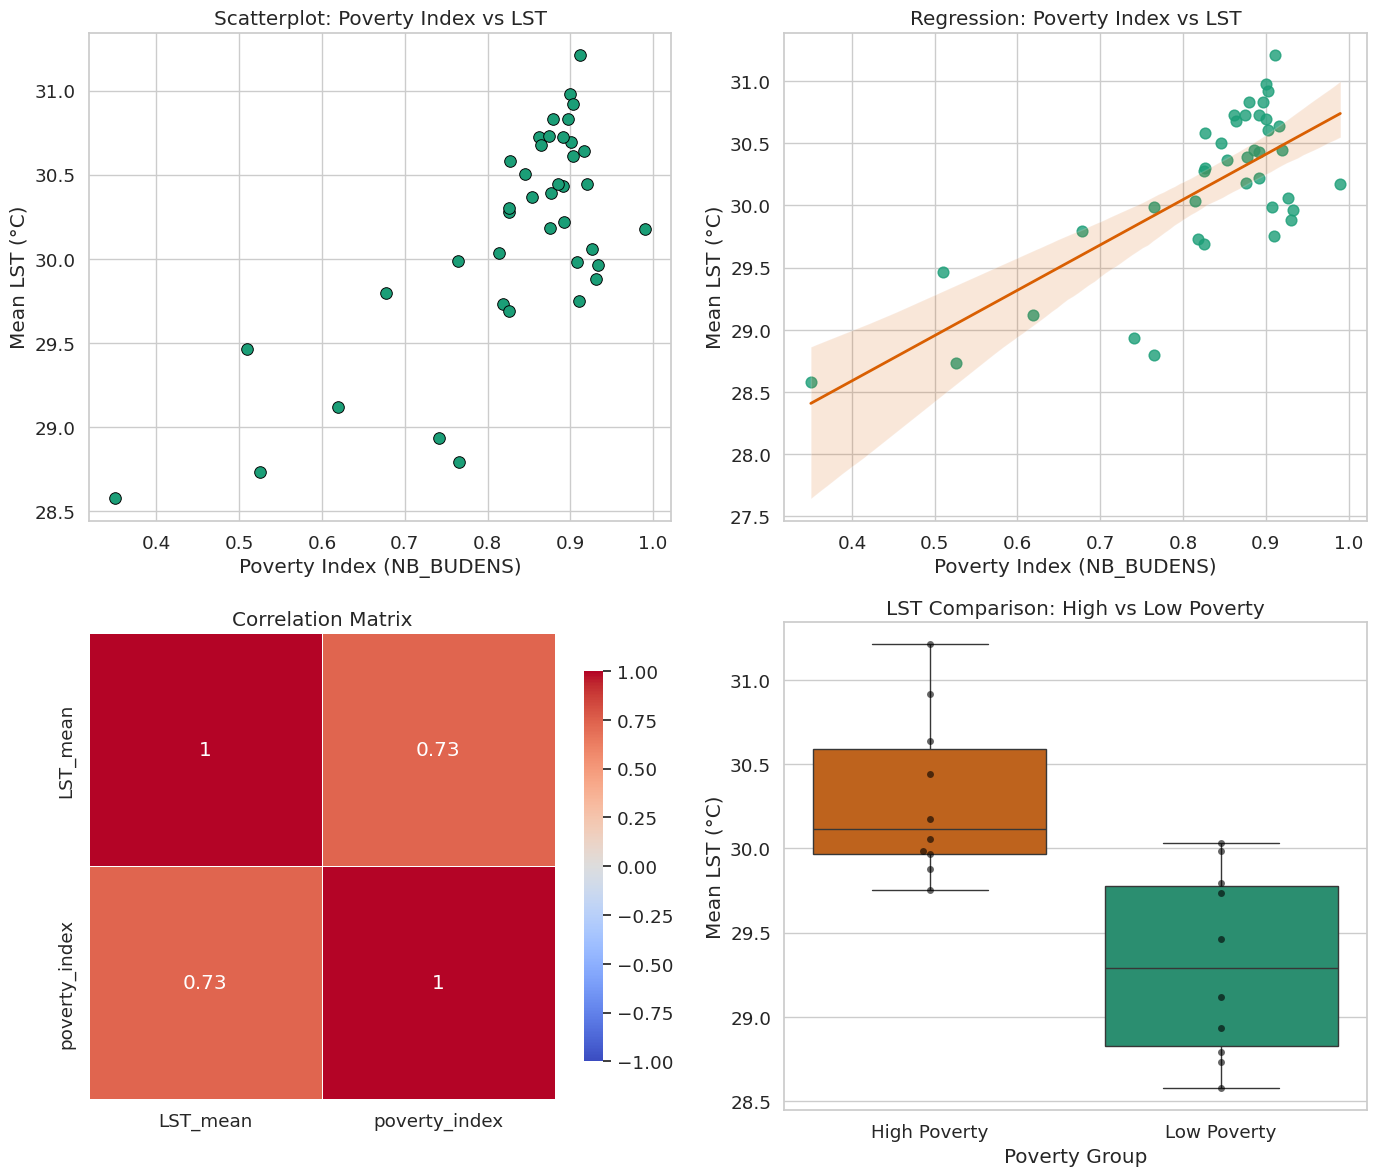

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", font_scale=1.2)

# Prepare combined DataFrame for boxplot
plot_df = pd.DataFrame({
    "LST_mean": list(high_lst) + list(low_lst),
    "Group": (["High Poverty"] * len(high_lst)) + (["Low Poverty"] * len(low_lst))
})

# Correlation matrix (extend if you have NDVI, NDBI, etc.)
corr_vars = df_merged[["LST_mean", "poverty_index"]]
corr_matrix = corr_vars.corr()

# Create 2×2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# -------------------------
# 1) Scatterplot
# -------------------------
sns.scatterplot(
    data=df_merged, x="poverty_index", y="LST_mean",
    color="#1b9e77", s=70, edgecolor="black", ax=axes[0, 0]
)
axes[0, 0].set_title("Scatterplot: Poverty Index vs LST")
axes[0, 0].set_xlabel("Poverty Index (NB_BUDENS)")
axes[0, 0].set_ylabel("Mean LST (°C)")

# -------------------------
# 2) Regression Plot
# -------------------------
sns.regplot(
    data=df_merged, x="poverty_index", y="LST_mean",
    scatter_kws={"s": 60, "color": "#1b9e77"},
    line_kws={"color": "#d95f02", "linewidth": 2},
    ax=axes[0, 1]
)
axes[0, 1].set_title("Regression: Poverty Index vs LST")
axes[0, 1].set_xlabel("Poverty Index (NB_BUDENS)")
axes[0, 1].set_ylabel("Mean LST (°C)")

# -------------------------
# 3) Correlation Heatmap
# -------------------------
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5,
    square=True, cbar_kws={"shrink": 0.8},
    ax=axes[1, 0]
)
axes[1, 0].set_title("Correlation Matrix")

# -------------------------
# 4) Boxplot: High vs Low Poverty
# -------------------------
sns.boxplot(
    data=plot_df, x="Group", y="LST_mean",
    palette=["#d95f02", "#1b9e77"], ax=axes[1, 1]
)
sns.swarmplot(
    data=plot_df, x="Group", y="LST_mean",
    color="black", alpha=0.6, ax=axes[1, 1]
)
axes[1, 1].set_title("LST Comparison: High vs Low Poverty")
axes[1, 1].set_xlabel("Poverty Group")
axes[1, 1].set_ylabel("Mean LST (°C)")

# -------------------------
# Final layout
# -------------------------
plt.tight_layout()
plt.show()
